# Comparative Scatter Analysis of $SMD$ Models for Twin-Fluid / Airblast Atomisers

**Project:** PLdV01 (#4085) — Comparative Scatter Analysis of Atomisation Models  
**Supervisor:** Prof. P.L. de Vaal, Ms Nyasha Chideme, Department of Chemical Engineering, University of Pretoria  
**Focus group:** Tribology  

---

## Objective

It compares eight published formulas for predicting droplet size in twin-fluid and airblast sprays. All eight try to predict the same thing — the Sauter Mean Diameter ($SMD$), the representative droplet size in a spray — but they give different answers for the same inputs. The goal is to measure how different, and to find out under what conditions they disagree the most.

$SMD$ matters because it sets how fast droplets evaporate, how far they penetrate a gas stream, and how much surface area is available for mixing. It is the standard metric in combustion design, pharmaceutical sprays, agricultural nozzles, and gasification.

No single formula is universally accepted. Each one was fitted to a specific atomiser on a specific range of fluids, so running the same operating point through different formulas can give droplet sizes that differ by a factor of 2 to 10. This notebook quantifies that gap.

## Which models are compared

Eight models in total, grouped into two sets:

**Literature set (M5–M8)** — four correlations from independent published sources. These are the main subject of the scatter analysis.
**Dissertation set (M1–M4)** — four correlations from Chideme & de Vaal (2024), the study this project builds on. They are shown in the plots for completeness but excluded from the main scatter statistics. Using them as a reference would bias the comparison toward the dissertation.

| # | Label | Source | Atomiser type |
|---|-------|--------|---------------|
| M1 | Chideme Eq. 5 | Chideme & de Vaal (2024) | Twin-fluid, viscous liquids |
| M2 | Chideme Eq. 6 | Chideme & de Vaal (2024) | Twin-fluid, viscous liquids |
| M3 | Chideme Eq. 7 | Chideme & de Vaal (2024) | Twin-fluid, non-viscous liquids |
| M4 | Chideme Eq. 8 | Chideme & de Vaal (2024) | Twin-fluid, non-viscous liquids |
| M5 | Lorenzetto & Lefebvre | Lorenzetto PhD (1976) via Urbán (2021) | Plain-jet airblast |
| M6 | Jasuja | Jasuja ASME (1982) | Plain-jet airblast |
| M7 | Lefebvre pre-filming | Lefebvre (1980) via Tareq et al. (2020) | Pre-filming airblast |
| M8 | Wachter et al. | Wachter, Jakobs & Kolb (2021) | External-mixing twin-fluid, pressure scaling |

## The equations

**M1 — Chideme & de Vaal Eq. 5** (viscous liquids, $\mu_l \geq 3 \times 10^{-3}$ Pa·s):

$$SMD = 7.588 \times 10^{-3} \left( \frac{\rho_A \, U_A^2}{U_R} \right)^{-0.5} \left( \frac{\mu_L}{\sigma_L \, \rho_L} \right)^{0.2}$$

**M2 — Chideme & de Vaal Eq. 6** (viscous liquids):

$$SMD = 5.626 \times 10^{-3} \; \frac{\mu_L^{\,0.2} \; \rho_L^{\,3 \times 10^{-26}}}{\rho_A^{\,0.8} \; \sigma_L^{\,9.2 \times 10^{-4}}}$$

**M3 — Chideme & de Vaal Eq. 7** (non-viscous liquids, $\mu_l < 3 \times 10^{-3}$ Pa·s):

$$SMD = 1.406 \times 10^{-3} \left( \frac{1}{\rho_A \, U_A} \right)^{0.5} \left( \frac{\mu_L}{\sigma_L \, \rho_L} \right)^{0.2}$$

**M4 — Chideme & de Vaal Eq. 8** (non-viscous liquids):

$$SMD = 1.896 \times 10^{-3} \; \frac{\mu_L^{\,0.5} \; \rho_L^{\,2 \times 10^{-21}}}{\rho_A \; \sigma_L^{\,2 \times 10^{-4}}}$$

**M5 — Lorenzetto & Lefebvre (1977)** (valid for $V_R \geq 70$ m/s):

$$SMD = 950 \times 10^{3} \; \frac{(\sigma \, W_l)^{0.33}}{V_R \; \rho_L^{0.37} \; \rho_A^{0.30}} \left(1 + \frac{1}{AFR}\right)^{1.7} + 127 \times 10^{3} \; \mu_L \left(\frac{d_0}{\sigma \, \rho_L}\right)^{0.5} \left(1 + \frac{1}{AFR}\right)^{1.8}$$

with $W_l$ = liquid mass flow rate [kg/s], $V_R = |U_g - U_l|$, and $AFR = \dot{m}_g / \dot{m}_l = GLR$. Output is in μm.

**M6 — Jasuja (1982)** (valid for $V_a \geq 55$ m/s):

$$SMD = 0.022 \left(\frac{\sigma}{\rho_A \, V_A^2}\right)^{0.45} \left(1 + \frac{1}{AFR}\right)^{0.5} + 14.3 \times 10^{-4} \left(\frac{\mu_L^2}{\sigma \, \rho_L}\right)^{0.4} \left(1 + \frac{1}{AFR}\right)^{0.8}$$

with $V_A = U_g$ and $AFR = GLR$. Output is in metres.

**M7 — Lefebvre pre-filming (1980)** (constants fitted to water data by Tareq et al. 2020):

$$\frac{SMD}{L_C} = 1.299 \left(\frac{\sigma}{\rho_A \, U_A^2 \, D_P}\right)^{0.5} \left(1 + \frac{\dot{m}_l}{\dot{m}_g}\right) + 34.184 \left(\frac{\mu_L^2}{\sigma \, \rho_L \, D_P}\right)^{0.5} \left(1 + \frac{\dot{m}_l}{\dot{m}_g}\right)$$

with $L_C$ = initial film thickness and $D_P$ = pre-filmer lip diameter.

**M8 — Wachter, Jakobs & Kolb (2021)** (external-mixing twin-fluid, pressure-dependent):

$$SMD = A(p) \, \exp\!\left(\frac{-J_{gas}}{B}\right) + C(p)$$

$$A(p) = 3.0 \, p^2 + 220 \;\; [\mu\text{m}], \qquad C(p) = 1.1 \, p + 67 \;\; [\mu\text{m}], \qquad B = 0.19 \;\; [\text{N}]$$

$$J_{gas} = v_{gas}^2 \; \rho_{gas} \; A_{gas} \;\; [\text{N}]$$

$p$ is system pressure in bar; output is in μm. M8 has no viscosity or surface-tension term — it was fitted only to water–air.


---
## Section 1 — Imports and configuration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize, LogNorm
from scipy import stats
import warnings
import itertools

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# Report / Word figure style
# ─────────────────────────────────────────────────────────────────────────────
# The displayed notebook figures stay moderate in size, while saved PNGs are
# exported at 300 dpi for Word/report insertion.
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 8.5,
    'axes.titlesize': 9.5,
    'axes.labelsize': 8.5,
    'legend.fontsize': 7.8,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'grid.linestyle': '--',
    'grid.linewidth': 0.45,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print("All imports successful.")
print(f"NumPy version  : {np.__version__}")
print(f"Pandas version : {pd.__version__}")


All imports successful.
NumPy version  : 1.26.4
Pandas version : 2.2.2


In [4]:
import os, pathlib

# ─────────────────────────────────────────────────────────────────────────────
# OUTPUT DIRECTORY SETUP — Word/report-ready figures
# ─────────────────────────────────────────────────────────────────────────────

NOTEBOOK_DIR = pathlib.Path.cwd()
PLOT_DIR     = NOTEBOOK_DIR / 'plots_word_ready'
PLOT_DIR.mkdir(exist_ok=True)

FIG_DPI = 300

MODEL_COLOURS = {
    'M1': '#534AB7', 'M2': '#AFA9EC',
    'M3': '#0F6E56', 'M4': '#5DCAA5',
    'M5': '#D85A30', 'M6': '#EF9F27',
    'M7': '#185FA5', 'M8': '#993556',
}
MODEL_LABELS = {
    'M1': 'M1 — Chideme Eq.5 (visc.)', 'M2': 'M2 — Chideme Eq.6 (visc.)',
    'M3': 'M3 — Chideme Eq.7 (non-visc.)', 'M4': 'M4 — Chideme Eq.8 (non-visc.)',
    'M5': 'M5 — Lorenzetto & Lefebvre', 'M6': 'M6 — Jasuja',
    'M7': 'M7 — Lefebvre pre-filming', 'M8': 'M8 — Wachter et al.',
}
MODEL_SHORT_LABELS = {
    'M1': 'M1 Eq.5', 'M2': 'M2 Eq.6', 'M3': 'M3 Eq.7', 'M4': 'M4 Eq.8',
    'M5': 'M5 L&L', 'M6': 'M6 Jasuja', 'M7': 'M7 pre-film', 'M8': 'M8 Wachter',
}

# Backwards-compatible names used by later cells.
colours = MODEL_COLOURS
labels  = MODEL_LABELS


def plot_path(filename):
    """Return the full path for saving a plot file next to this notebook."""
    return str(PLOT_DIR / filename)


def save_report_figure(fig, filename, dpi=FIG_DPI):
    """Save a figure as a high-resolution, Word-ready PNG."""
    if not filename.lower().endswith('.png'):
        filename = f'{filename}.png'
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white', edgecolor='none')
    return path


def format_log_axis(ax, which='both'):
    """Make log axes cleaner for compact report figures."""
    if which in ('x', 'both'):
        ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    if which in ('y', 'both'):
        ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(which='major', length=3.2, width=0.7)
    ax.tick_params(which='minor', length=2.0, width=0.5)


def add_panel_label(ax, label):
    ax.text(0.02, 0.98, label, transform=ax.transAxes,
            ha='left', va='top', fontsize=9, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=1.5))

print(f"Word-ready plots will be saved to: {PLOT_DIR}")
print(f"Directory created: {PLOT_DIR.exists()}")


Word-ready plots will be saved to: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready
Directory created: True


---

## Section 2 — Parameters and sweep ranges

### What is swept and what isn't

Five parameters are swept: $GLR$, liquid viscosity $\mu_l$, surface tension $\sigma$, nozzle diameter $d_0$, and liquid density $\rho_l$. Everything else is held fixed.

Two geometry settings are deliberately left fixed: the M7 pre-filmer dimensions ($L_C$, $D_P$) and the M8 annulus dimensions ($s_{gas}$, $D_{liq}$). These are specific to the nozzles those two models were calibrated on. Varying them would push M7 and M8 outside the range their fitted constants were built for, and they would disagree with M5 and M6 for a bad reason (bad calibration) instead of a good one (different physics).

### Baseline values

The baseline values below are used (a) to slice the sweep in plots that need "water-like, 1 mm nozzle" as the reference point, and (b) as fixed values for the non-swept parameters.

| Parameter | Symbol | Baseline | Swept? | Notes |
|-----------|--------|---------|--------|-------|
| Nozzle orifice diameter | $d_0$ | 1.0 mm | **yes** | Enters $We$, $Re$, $Oh$. Also sets $A_l = \pi d_0^2/4$. |
| Gas port diameter | $D_\text{gas,port}$ | 2.0 mm | no | Fixed; sets $A_g$. |
| Liquid density | $\rho_l$ | 998 kg/m³ | **yes** | Enters $Re$ and $Oh$. |
| Gas density | $\rho_g$ | 1.2 kg/m³ | no | Air at ~20 °C, 1 atm. |
| Gas pressure | $P_g$ | 200 kPa | no | Section 9 varies this for M8 only. |
| Liquid viscosity | $\mu_l$ | — | **yes** | |
| Surface tension | $\sigma$ | — | **yes** | |
| GLR | — | — | **yes** | |

### Geometry for the individual models (fixed)

- **M5 (Lorenzetto & Lefebvre):** $W_l$ from $\dot{m}_l$; $V_R = U_g - U_l$.
- **M6 (Jasuja):** $AFR = \dot{m}_g / \dot{m}_l = GLR$; $V_a = U_g$.
- **M7 (Lefebvre pre-filming):** $L_C$ = 0.55 mm, $D_P$ = 8.46 mm — Tareq et al. (2020).
- **M8 (Wachter et al.):** $s_{gas}$ = 1.2 mm, $D_{liq}$ = 2 mm; $A_{gas}$ from annular geometry.

### Sweep grid

| Parameter | Range | Steps | Scale |
|-----------|-------|-------|-------|
| $GLR$ | 0.02 – 2.7 | 40 | Linear |
| $\mu_l$ | 1 – 20 mPa·s | 20 | Log |
| $\sigma$ | 22 – 73 mN/m | 20 | Linear |
| $d_0$ | 0.5 – 2.0 mm | 4 | Linear |
| $\rho_l$ | 800 – 1300 kg/m³ | 3 | Linear |

Total: **40 × 20 × 20 × 4 × 3 = 192 000 test cases**.

The $d_0$ range covers typical lab-scale twin-fluid atomiser orifices. The $\rho_l$ range covers diesel-like (~800 kg/m³), water (998), and heavier glycerol-water or brine-like liquids (~1300). Including $\rho_l$ in the sweep matters because without it, $Re$ and $Oh$ are nearly perfectly correlated across the dataset (both dominated by $\mu_l$), and we need them to vary independently so the plots in Section 8 can separate viscosity effects from inertia effects.


In [6]:
# ─────────────────────────────────────────────────────────────────────
# BASELINE PHYSICAL PARAMETERS
# All values in SI units unless explicitly noted.
# ─────────────────────────────────────────────────────────────────────

# --- Baseline geometry ---
d0_baseline = 1.0e-3          # Reference nozzle diameter [m] — used for plot slicing
D_gas_port  = 2.0e-3          # Gas port diameter [m] — FIXED across sweep
A_g         = np.pi/4 * D_gas_port**2   # Gas orifice area [m²] — FIXED

# --- Baseline fluid properties (mu, sigma, rho_l all swept) ---
rho_l_baseline = 998.0        # Water at 20 °C [kg/m³] —
rho_g          = 1.2          # Gas (air) density [kg/m³] — 
mu_l_baseline  = 1.0e-3       # Water at 20 °C [Pa·s] — reference only
sigma_baseline = 72.8e-3      # Water at 20 °C [N/m]  — reference only
P_g            = 200e3        # Gas supply pressure [Pa] —

d0, rho_l, mu_l, sigma = d0_baseline, rho_l_baseline, mu_l_baseline, sigma_baseline
A_l = np.pi/4 * d0**2          # Reference liquid orifice area

# --- M7 (Lefebvre pre-filming) geometry — FIXED (model-specific calibration) ---
L_C = 0.55e-3                  # Characteristic length = initial film thickness [m]
D_P = 8.46e-3                  # Pre-filmer lip diameter [m]

# --- M8 (Wachter et al.) geometry — FIXED (model-specific calibration) ---
s_gas   = 1.2e-3               # Gas annular gap width [m]
D_liq_W = 2.0e-3               # Liquid jet diameter used by Wachter [m]
D_gas_W = D_liq_W + 2*s_gas    # Outer gas annulus diameter [m]
A_gas_W = np.pi/4 * (D_gas_W**2 - D_liq_W**2)   # Gas annulus area [m²]

# ─────────────────────────────────────────────────────────────────────
# PARAMETRIC SWEEP RANGES — 5 independent dimensions
# ─────────────────────────────────────────────────────────────────────

GLR_range   = np.linspace(0.02, 2.7, 40)             # Gas-to-liquid mass flow ratio [-]
mu_range    = np.logspace(np.log10(1e-3),
                          np.log10(20e-3), 20)        # Viscosity 1–20 mPa·s  [Pa·s]
sigma_range = np.linspace(22e-3, 73e-3, 20)          # Surface tension 22–73 mN/m [N/m]
d0_range    = np.array([0.5e-3, 1.0e-3, 1.5e-3, 2.0e-3])   # Nozzle diameter [m]
rho_l_range = np.array([800.0, 998.0, 1300.0])        # Liquid density [kg/m³]

# Discretised GLR levels for grouped analysis
GLR_levels  = np.array([0.1, 0.3, 0.6, 1.2, 2.4])

# Viscosity threshold separating viscous from non-viscous regimes (Chideme)
MU_THRESHOLD = 3e-3   # [Pa·s]

# ─── Report the sweep dimensionality ───────────────────────────────────
n_total = (len(GLR_range) * len(mu_range) * len(sigma_range)
           * len(d0_range) * len(rho_l_range))
print('Baseline / reference values (also used for slicing in plots):')
print(f'  d_0_baseline   = {d0_baseline*1e3:.1f} mm')
print(f'  rho_l_baseline = {rho_l_baseline:.1f} kg/m³')
print(f'  A_g (fixed)    = {A_g*1e6:.4f} mm²   (2-mm gas port)')
print(f'  rho_g (fixed)  = {rho_g:.2f} kg/m³')
print()
print('Sweep grid (5 independent dimensions):')
print(f'  GLR    : {len(GLR_range):3d} values  ({GLR_range[0]:.2f} – {GLR_range[-1]:.2f})')
print(f'  mu_l   : {len(mu_range):3d} values  ({mu_range[0]*1e3:.2f} – {mu_range[-1]*1e3:.2f} mPa·s)')
print(f'  sigma  : {len(sigma_range):3d} values  ({sigma_range[0]*1e3:.1f} – {sigma_range[-1]*1e3:.1f} mN/m)')
print(f'  d_0    : {len(d0_range):3d} values  ({d0_range[0]*1e3:.2f} – {d0_range[-1]*1e3:.2f} mm)')
print(f'  rho_l  : {len(rho_l_range):3d} values  ({rho_l_range[0]:.0f} – {rho_l_range[-1]:.0f} kg/m³)')
print(f'  Total  : {n_total:,} test cases')


Baseline / reference values (also used for slicing in plots):
  d_0_baseline   = 1.0 mm
  rho_l_baseline = 998.0 kg/m³
  A_g (fixed)    = 3.1416 mm²   (2-mm gas port)
  rho_g (fixed)  = 1.20 kg/m³

Sweep grid (5 independent dimensions):
  GLR    :  40 values  (0.02 – 2.70)
  mu_l   :  20 values  (1.00 – 20.00 mPa·s)
  sigma  :  20 values  (22.0 – 73.0 mN/m)
  d_0    :   4 values  (0.50 – 2.00 mm)
  rho_l  :   3 values  (800 – 1300 kg/m³)
  Total  : 192,000 test cases


---

## Section 3 — Velocities and dimensionless groups

### Converting $GLR$ to velocities

The models take nozzle-exit velocities as inputs, but the sweep uses $GLR$ (gas-to-liquid mass-flow ratio). With liquid flow rate $\dot{m}_l$ fixed at a representative value:

$$U_g = \frac{\dot{m}_g}{\rho_g \cdot A_g} \qquad U_l = \frac{\dot{m}_l}{\rho_l \cdot A_l} \qquad U_R = |U_g - U_l|$$

$U_g$ is the gas exit velocity, $U_l$ is the liquid exit velocity, $U_R$ is the relative velocity between the two phases (this is what drives aerodynamic breakup).

### The three dimensionless groups

These three numbers determine which atomisation regime a spray is in, and they show up repeatedly in the analysis.

**Weber number** ($We$) — aerodynamic force vs. surface tension. A big $We$ means gas drag dominates and the droplet will break up. A small $We$ means surface tension holds the droplet together.

$$We = \frac{\rho_g \cdot U_R^2 \cdot d_0}{\sigma}$$

**Reynolds number** ($Re$) — liquid inertia vs. liquid viscosity. A big $Re$ means the liquid is turbulent and thin; a small $Re$ means it is viscous and sluggish.

$$Re = \frac{\rho_l \cdot U_l \cdot d_0}{\mu_l}$$

**Ohnesorge number** ($Oh$) — viscous forces vs. inertial and surface-tension forces combined.

$$Oh = \frac{\mu_l}{\sqrt{\rho_l \cdot \sigma \cdot d_0}}$$

$Oh$ is useful because it doesn't depend on velocity. It tells you what atomisation regime a given fluid in a given nozzle belongs to before you know how fast it is flowing.


In [8]:
def compute_velocities(GLR, rho_l, rho_g, A_g, A_l, mdot_l=3.77e-4):
    """
    Compute gas velocity, liquid velocity, and relative velocity from GLR.

    Parameters
    ----------
    GLR    : float — gas-to-liquid mass flow ratio [-]
    rho_l  : float — liquid density [kg/m³]
    rho_g  : float — gas (air) density [kg/m³]
    A_g    : float — gas orifice cross-sectional area [m²]
    A_l    : float — liquid orifice cross-sectional area [m²]
    mdot_l : float — liquid mass flow rate [kg/s], default ~50 g/h

    Returns
    -------
    U_g, U_l, U_R : float — gas velocity, liquid velocity, relative velocity [m/s]

    Notes
    -----
    The liquid mass flow rate mdot_l is fixed at a representative baseline.
    Gas mass flow is then derived from GLR: mdot_g = GLR * mdot_l.
    This ensures velocities are physically consistent with the nozzle geometry.
    """
    mdot_g = GLR * mdot_l
    U_g    = mdot_g / (rho_g * A_g)
    U_l    = mdot_l / (rho_l * A_l)
    U_R    = abs(U_g - U_l)
    return U_g, U_l, U_R


def compute_dimensionless(rho_g, rho_l, U_R, U_l, mu_l, sigma, d0):
    """
    Compute the three primary dimensionless groups governing atomisation.

    Parameters
    ----------
    rho_g  : float — gas density [kg/m³]
    rho_l  : float — liquid density [kg/m³]
    U_R    : float — relative velocity between gas and liquid [m/s]
    U_l    : float — liquid velocity [m/s]
    mu_l   : float — liquid dynamic viscosity [Pa·s]
    sigma  : float — liquid surface tension [N/m]
    d0     : float — nozzle orifice diameter [m]

    Returns
    -------
    We, Re, Oh : float — Weber, Reynolds, Ohnesorge numbers [-]
    """
    We = rho_g * U_R**2 * d0 / sigma          # Aerodynamic Weber number
    Re = rho_l * U_l  * d0 / mu_l             # Liquid Reynolds number
    Oh = mu_l / np.sqrt(rho_l * sigma * d0)   # Ohnesorge number (property-based)
    return We, Re, Oh


# Quick sanity check at baseline conditions
GLR_test = 0.5
U_g_t, U_l_t, U_R_t = compute_velocities(GLR_test, rho_l, rho_g, A_g, A_l)
We_t, Re_t, Oh_t     = compute_dimensionless(rho_g, rho_l, U_R_t, U_l_t, mu_l, sigma, d0)

print("Sanity check at GLR=0.5, baseline fluid properties:")
print(f"  U_g = {U_g_t:.2f} m/s")
print(f"  U_l = {U_l_t:.4f} m/s")
print(f"  U_R = {U_R_t:.2f} m/s")
print(f"  We  = {We_t:.1f}")
print(f"  Re  = {Re_t:.1f}")
print(f"  Oh  = {Oh_t:.5f}")


Sanity check at GLR=0.5, baseline fluid properties:
  U_g = 50.00 m/s
  U_l = 0.4810 m/s
  U_R = 49.52 m/s
  We  = 40.4
  Re  = 480.0
  Oh  = 0.00371


---

## Section 4 — The eight $SMD$ model functions

Each model is implemented as a Python function with the same call signature so they can all be called in a loop. Each returns $SMD$ in metres; unit conversions happen inside the function.

A few practical notes:

- **M1 and M2** only apply when $\mu_l \geq 3$ mPa·s (viscous regime). **M3 and M4** only apply when $\mu_l < 3$ mPa·s (non-viscous). A routing function handles the switch.
- **M5's** constants (950×10³ and 127×10³) are dimensional rather than dimensionless. This is a known quirk of the original Lorenzetto (1976) thesis; Lefebvre acknowledged it in later work.
- **M6** uses $AFR = GLR$ directly. Equation from Jasuja's ASME 82-GT-32 paper.
- **M7** returns $SMD/L_C$ (dimensionless) inside, then multiplies by $L_C$ to get metres. Constants 1.299 and 34.184 were fitted to water data by Tareq et al. (2020).
- **M8** expects pressure in bar (converted from Pa internally) and returns μm (converted to metres). It has no fluid-property terms at all — it was fitted only to water–air.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL 1 — Chideme & de Vaal (2024), Equation 5
# Weber and Reynolds derivation for VISCOUS liquids (μ_l > 3×10⁻³ Pa·s)
# ─────────────────────────────────────────────────────────────────────────────

def model_M1(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0, **kwargs):
    """
    Chideme & de Vaal (2024), Eq. 5 — Weber & Reynolds derivation, viscous liquids.

    Equation:
        SMD = 7.588e-3 * (rho_A * U_A^2 / U_R)^-0.5 * (mu_L / (sigma_L * rho_L))^0.2

    Validity:
        - Liquid viscosity: μ_l > 3×10⁻³ kg/(m·s)   [viscous regime]
        - Air pressure: 100–840 kPag
        - Nozzle diameter d0 = 1 mm (internal mixing twin-fluid)
        - Validated against ethylene glycol-water mixtures and diesel

    Parameters: U_g [m/s], U_l [m/s], U_R [m/s], rho_g [kg/m³], rho_l [kg/m³],
                mu_l [Pa·s], sigma [N/m], d0 [m]
    Returns: SMD [m]
    """
    term1 = (rho_g * U_g**2 / U_R)**(-0.5)
    term2 = (mu_l / (sigma * rho_l))**0.2
    return 7.588e-3 * term1 * term2


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 2 — Chideme & de Vaal (2024), Equation 6
# Non-polynomial power-curve fit for VISCOUS liquids (μ_l > 3×10⁻³ Pa·s)
# ─────────────────────────────────────────────────────────────────────────────

def model_M2(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0, **kwargs):
    """
    Chideme & de Vaal (2024), Eq. 6 — Non-polynomial fit, viscous liquids.

    Equation:
        SMD = 5.626e-3 * (mu_L^0.2 * rho_L^(3e-26)) / (rho_A^0.8 * sigma_L^(9.2e-4))

    Validity: same as M1 — viscous regime only, 100–840 kPag
    Returns: SMD [m]
    """
    numerator   = mu_l**0.2 * rho_l**(3e-26)
    denominator = rho_g**0.8 * sigma**(9.2e-4)
    return 5.626e-3 * (numerator / denominator)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 3 — Chideme & de Vaal (2024), Equation 7
# Weber derivation for NON-VISCOUS liquids (μ_l < 3×10⁻³ Pa·s)
# ─────────────────────────────────────────────────────────────────────────────

def model_M3(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0, **kwargs):
    """
    Chideme & de Vaal (2024), Eq. 7 — Weber derivation, non-viscous liquids.

    Equation:
        SMD = 1.406e-3 * (1 / (rho_A * U_A))^0.5 * (mu_L / (sigma_L * rho_L))^0.2

    Validity:
        - Liquid viscosity: μ_l < 3×10⁻³ kg/(m·s)   [non-viscous regime]
        - Air pressure: 100–840 kPag
        - Validated against ethanol-water mixtures

    Returns: SMD [m]
    """
    term1 = (1.0 / (rho_g * U_g))**0.5
    term2 = (mu_l / (sigma * rho_l))**0.2
    return 1.406e-3 * term1 * term2


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 4 — Chideme & de Vaal (2024), Equation 8
# Non-polynomial power-curve fit for NON-VISCOUS liquids (μ_l < 3×10⁻³ Pa·s)
# ─────────────────────────────────────────────────────────────────────────────

def model_M4(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0, **kwargs):
    """
    Chideme & de Vaal (2024), Eq. 8 — Non-polynomial fit, non-viscous liquids.

    Equation:
        SMD = 1.896e-3 * (mu_L^0.5 * rho_L^(2e-21)) / (rho_A * sigma_L^(2e-4))

    Validity: same as M3 — non-viscous regime only, 100–840 kPag
    Returns: SMD [m]
    """
    numerator   = mu_l**0.5 * rho_l**(2e-21)
    denominator = rho_g * sigma**(2e-4)
    return 1.896e-3 * (numerator / denominator)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 5 — Lorenzetto & Lefebvre (1977), from Lorenzetto PhD thesis (1976)
# Plain-jet airblast atomiser — original empirical constants
# ─────────────────────────────────────────────────────────────────────────────

def model_M5(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0,
             mdot_l=3.77e-4, mdot_g=None, **kwargs):
    """
    Lorenzetto & Lefebvre (1977), Eq. 24 from Lorenzetto PhD thesis (1976),
    reproduced as Eq. 4.6 in Urbán (2021).

    Equation:
        SMD = 950e3 * (sigma*W_l)^0.33 / (V_R * rho_l^0.37 * rho_g^0.30) * (1+1/AFR)^1.7
            + 127e3 * mu_l * (d0/(sigma*rho_l))^0.5 * (1+1/AFR)^1.8

    where:
        W_l = liquid mass flux = mdot_l / A_l  [kg/(m²·s)]
        V_R = relative velocity = U_R           [m/s]
        AFR = air-to-fuel (air-to-liquid) mass ratio = mdot_g / mdot_l
            Note: AFR = ALR = GLR — different names used by different authors
            for the same ratio (ṁ_gas / ṁ_liquid). Lorenzetto uses AFR,
            Tareq et al. use ALR, Chideme uses GLR. All identical.

    Physical interpretation:
        Two-term structure: the first term captures surface-tension-dominated
        breakup scaled by the liquid mass flux; the second term captures the
        viscosity contribution. The (1+1/AFR) factor accounts for the dilution
        of atomising energy by excess air.

    Important note on constants:
        The constants 950×10³ and 127×10³ carry dimensional units (m^0.33 and
        m^0.60 respectively). Lefebvre later acknowledged this dimensional
        inconsistency. The equation is empirically accurate within its original
        experimental range but should not be extrapolated without caution.

    Validity:
        - Liquid viscosity: 1.0–76×10⁻³ Pa·s
        - Surface tension: 26–73×10⁻³ N/m
        - Liquid density: 794–2180 kg/m³
        - Relative velocity: 70–180 m/s
        - Orifice diameter: 0.39–1.58 mm

    Returns: SMD [m]
    """
    # W_l is the liquid mass flow rate [kg/s] — NOT mass flux.
    # Lorenzetto (1976) defines W as 'mass flow rate, gr/s'; the constant 950e3
    # is calibrated for W_l in kg/s with SMD returned in μm.
    W_l      = mdot_l                     # Liquid mass flow rate [kg/s]
    V_R      = U_R                        # Relative velocity [m/s]
    if mdot_g is None:
        mdot_g_val = mdot_l               # Fallback: will be overridden by sweep
    else:
        mdot_g_val = mdot_g
    AFR = mdot_g_val / mdot_l if mdot_l > 0 else 1.0

    # Validity check: M5 requires V_R >= 70 m/s (Lorenzetto 1976 experimental range)
    if V_R < 70.0:
        return np.nan

    term1 = 950e3 * (sigma * W_l)**0.33 / (V_R * rho_l**0.37 * rho_g**0.30)             * (1 + 1.0/AFR)**1.7
    term2 = 127e3 * mu_l * (d0 / (sigma * rho_l))**0.5             * (1 + 1.0/AFR)**1.8

    SMD_um = term1 + term2   # [μm] — Lorenzetto equation output is in μm
    return SMD_um * 1e-6     # Convert to metres


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 6 — Jasuja (1982), plain-jet airblast
# Derived from high-pressure gas turbine fuel atomisation experiments
# ─────────────────────────────────────────────────────────────────────────────

def model_M6(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0,
             mdot_l=3.77e-4, mdot_g=None, **kwargs):
    """
    Jasuja (1982), ASME 82-GT-32, conclusion equation.

    Equation:
        SMD = 0.022 * (sigma / (rho_a * V_a^2))^0.45 * (1 + 1/AFR)^0.5
            + 14.3e-4 * (mu_l^2 / (sigma * rho_l))^0.4 * (1 + 1/AFR)^0.8

    where:
        V_a = atomising air velocity = U_g  [m/s]
        AFR = air-to-fuel (air-to-liquid) mass ratio = mdot_g / mdot_l
            Note: AFR = ALR = GLR — same physical ratio, different naming
            conventions across the literature.

    Physical interpretation:
        Similar two-term structure to M5. The first term (Weber-type) dominates
        for low-viscosity fuels like kerosine; the second term (viscosity-type)
        becomes progressively more important for heavy, viscous fuels like the
        R55 residual fuel oil blend used in the original experiments.

        The exponent 0.45 on the Weber group (vs 0.5 for a simple We⁻⁰·⁵) reflects
        the influence of air pressure on atomisation at the high-pressure conditions
        (up to 14 atm) covered in the study.

    Validity:
        - Liquid viscosity: 0.001–0.035 Pa·s
        - Surface tension: 0.027–0.074 N/m
        - Air velocity: 55–150 m/s
        - Air pressure: 1–14 atm
        - AFR: 2–12

    Returns: SMD [m]
    """
    V_a = U_g
    if mdot_g is None:
        mdot_g_val = mdot_l
    else:
        mdot_g_val = mdot_g
    AFR = mdot_g_val / mdot_l if mdot_l > 0 else 1.0

    # Validity check: Jasuja (1982) calibrated for V_a = 55–150 m/s
    if V_a < 55.0:
        return np.nan

    term1 = 0.022 * (sigma / (rho_g * V_a**2))**0.45 * (1 + 1.0/AFR)**0.5
    term2 = 14.3e-4 * (mu_l**2 / (sigma * rho_l))**0.4 * (1 + 1.0/AFR)**0.8

    SMD = term1 + term2
    return SMD


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 7 — Lefebvre pre-filming airblast (1980), water-fitted constants
# From Tareq et al. (2020), Equations 3 and 4
# ─────────────────────────────────────────────────────────────────────────────

def model_M7(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0,
             mdot_l=3.77e-4, mdot_g=None,
             L_C=0.55e-3, D_P=8.46e-3, **kwargs):
    """
    Lefebvre (1980), empirical formula for pre-filming airblast nozzle,
    with water-fitted constants A=1.299, B=34.184 from Tareq et al. (2020).

    Equation:
        SMD / L_C = A * (sigma / (rho_A * U_A^2 * D_P))^0.5 * (1 + mdot_l/mdot_g)
                  + B * (mu_L^2 / (sigma * rho_L * D_P))^0.5 * (1 + mdot_l/mdot_g)

    where:
        L_C = characteristic length = initial liquid film thickness [m]
        D_P = pre-filmer lip diameter [m]
        A   = 1.299  (fitted to water spray data)
        B   = 34.184 (fitted to water spray data)

    Physical interpretation:
        The pre-filming mechanism spreads liquid into a thin sheet before it
        encounters the high-velocity air. This means both the film thickness L_C
        and the pre-filmer diameter D_P are structurally important — unlike the
        plain-jet models where only the orifice diameter d0 matters.

        The (1 + ṁ_l/ṁ_a) term = (1 + 1/ALR) penalises conditions where the
        liquid-to-air ratio is high (poor atomisation quality).

    Note on constants:
        A and B were fitted to water (Jet A-1 would give A=5.243, B=22.995).
        Using water constants is conservative — water has higher surface tension
        than most fuels, which gives larger predicted SMD values.

    Validity:
        - Pre-filming airblast nozzle geometry (not valid for plain-jet or coaxial)
        - ALR: 5–15
        - Air pressure difference: 3–5%
        - Working fluids: water and Jet A-1

    Returns: SMD [m]
    """
    U_A = U_g
    if mdot_g is None:
        mdot_g_val = mdot_l
    else:
        mdot_g_val = mdot_g
    liquid_air_ratio = mdot_l / mdot_g_val if mdot_g_val > 0 else 1.0

    A_coeff = 1.299
    B_coeff = 34.184

    term1 = A_coeff * (sigma / (rho_g * U_A**2 * D_P))**0.5 * (1 + liquid_air_ratio)
    term2 = B_coeff * (mu_l**2 / (sigma * rho_l * D_P))**0.5 * (1 + liquid_air_ratio)

    SMD_over_LC = term1 + term2
    SMD = SMD_over_LC * L_C   # Convert dimensionless ratio back to metres
    return SMD


# ─────────────────────────────────────────────────────────────────────────────
# MODEL 8 — Wachter, Jakobs & Kolb (2021), pressure-scaling empirical model
# External-mixing twin-fluid atomiser at elevated system pressure
# ─────────────────────────────────────────────────────────────────────────────

def model_M8(U_g, U_l, U_R, rho_g, rho_l, mu_l, sigma, d0,
             P_g=200e3, A_gas_W=A_gas_W, **kwargs):
    """
    Wachter, Jakobs & Kolb (2021), Applications in Energy and Combustion Science,
    Equations 8, 9, and 10.

    Equations:
        ID32 = A(p) * exp(-J_gas / B) + C(p)    [μm]
        A(p) = 3.0 * p^2 + 220                   [p in bar]
        C(p) = 1.1 * p + 67
        B    = 0.19                               [N, constant]
        J_gas = v_gas^2 * rho_gas * A_gas         [N]

    Physical interpretation:
        This model characterises atomisation through the concept of gas momentum flow
        J_gas (units: N = kg·m/s²·m = N), which captures the total mechanical power
        available from the gas phase for liquid disintegration. Unlike the other models,
        which use velocity and density separately, J_gas unifies gas velocity, gas density
        (i.e., system pressure at constant composition), and nozzle exit area into one
        variable.

        The exponential decay form reflects the observed saturation behaviour at high
        J_gas: beyond a certain gas momentum, further increases produce diminishing
        returns in droplet refinement (asymptote at C(p)).

        The pressure-dependent parameters A(p) and C(p) capture the shift in this
        exponential curve as system pressure increases.

    Critical unit notes:
        1. P_g is supplied in Pa (SI) but the model requires bar — conversion applied internally
        2. SMD is returned in μm by the model — converted to metres before returning
        3. Liquid properties (mu_l, sigma, rho_l) do NOT appear — this model is
           property-agnostic and was fitted exclusively to water-air at T=20°C

    Validity:
        - System pressure: 1–21 bar (1×10⁵ – 2.1×10⁶ Pa)
        - Gas momentum flow J_gas: 0.07–2.5 N
        - Gas velocity: 60–100 m/s
        - Gas gap width: 0.6–2.0 mm  (s_gas = 1.2 mm fixed in this study)
        - Liquid: water only (no liquid property terms in equation)
        - Liquid mass flow: 20 kg/h fixed

    Returns: SMD [m]
    """
    # Unit conversion: Pa → bar
    p_bar = P_g / 1e5

    # Gas momentum flow [N] — the primary driving variable
    J_gas = U_g**2 * rho_g * A_gas_W

    # Pressure-dependent parameters
    A_param = 3.0 * p_bar**2 + 220.0   # [μm]
    C_param = 1.1 * p_bar + 67.0       # [μm]
    B_param = 0.19                     # [N], constant

    # Protect against J_gas = 0 (would give exp(0) = 1, which is fine,
    # but let's be explicit about the calculation)
    SMD_um = A_param * np.exp(-J_gas / B_param) + C_param   # [μm]

    # Convert to metres for consistency with all other models
    SMD_m = SMD_um * 1e-6
    return SMD_m

---

## Section 5 — Model routing

`evaluate_all_models` is the master function. For one set of inputs it computes the velocities and dimensionless groups, then runs all eight models and returns everything in a dict.

If a model cannot be evaluated — for example division by zero when $U_R = 0$, or a velocity below the model's valid range, or the wrong viscosity regime for M1–M4 — the function returns `NaN` instead of crashing. The sweep then completes cleanly and gaps show up transparently in the dataset.


In [12]:
def evaluate_all_models(GLR, rho_l, rho_g, mu_l, sigma, d0, P_g,
                        A_g, A_l, A_gas_W, L_C, D_P,
                        mdot_l=3.77e-4):
    """
    Master evaluation function: computes velocities, dimensionless groups,
    and calls all 8 SMD models for a single set of input conditions.

    The Chideme models M1/M2 and M3/M4 are routed by viscosity regime:
        - μ_l >= MU_THRESHOLD  →  M1, M2 active  |  M3, M4 = NaN
        - μ_l <  MU_THRESHOLD  →  M3, M4 active  |  M1, M2 = NaN

    Models M5–M8 are evaluated regardless of viscosity regime, with the
    understanding that they may not be physically appropriate for all fluids.

    Parameters
    ----------
    GLR    : float — gas-to-liquid mass flow ratio
    rho_l  : float — liquid density [kg/m³]
    rho_g  : float — gas density [kg/m³]
    mu_l   : float — liquid dynamic viscosity [Pa·s]
    sigma  : float — surface tension [N/m]
    d0     : float — orifice diameter [m]
    P_g    : float — gas pressure [Pa]
    A_g    : float — gas orifice area [m²]
    A_l    : float — liquid orifice area [m²]
    A_gas_W: float — gas annulus area for M8 [m²]
    L_C    : float — film thickness for M7 [m]
    D_P    : float — pre-filmer diameter for M7 [m]
    mdot_l : float — liquid mass flow rate [kg/s]

    Returns
    -------
    dict with keys: U_g, U_l, U_R, We, Re, Oh,
                    M1, M2, M3, M4, M5, M6, M7, M8 (all SMD in metres),
                    GLR, mu_l, sigma, rho_l, rho_g, P_g
    """
    # ── Velocities ──────────────────────────────────────────────────────────
    U_g, U_l, U_R = compute_velocities(GLR, rho_l, rho_g, A_g, A_l, mdot_l)
    mdot_g        = GLR * mdot_l

    # Guard: if U_R is zero the Weber-based models divide by zero
    if U_R < 1e-10:
        U_R = 1e-10

    # ── Dimensionless groups ─────────────────────────────────────────────────
    We, Re, Oh = compute_dimensionless(rho_g, rho_l, U_R, U_l, mu_l, sigma, d0)

    # ── Common keyword dict for model calls ──────────────────────────────────
    kw = dict(U_g=U_g, U_l=U_l, U_R=U_R,
              rho_g=rho_g, rho_l=rho_l, mu_l=mu_l, sigma=sigma, d0=d0,
              mdot_l=mdot_l, mdot_g=mdot_g,
              P_g=P_g, A_gas_W=A_gas_W, L_C=L_C, D_P=D_P)

    # ── Viscosity routing for Chideme models ─────────────────────────────────
    if mu_l >= MU_THRESHOLD:
        # VISCOUS regime — M1 and M2 active
        smd_M1 = model_M1(**kw)
        smd_M2 = model_M2(**kw)
        smd_M3 = np.nan   # Not applicable in viscous regime
        smd_M4 = np.nan
    else:
        # NON-VISCOUS regime — M3 and M4 active
        smd_M1 = np.nan   # Not applicable in non-viscous regime
        smd_M2 = np.nan
        smd_M3 = model_M3(**kw)
        smd_M4 = model_M4(**kw)

    # ── Independent models (evaluated regardless of viscosity regime) ────────
    smd_M5 = model_M5(**kw)
    smd_M6 = model_M6(**kw)
    smd_M7 = model_M7(**kw)
    smd_M8 = model_M8(**kw)

    return {
        # Flow conditions
        'GLR': GLR, 'mu_l': mu_l, 'sigma': sigma,
        'rho_l': rho_l, 'rho_g': rho_g, 'P_g': P_g,
        # Velocities
        'U_g': U_g, 'U_l': U_l, 'U_R': U_R,
        # Dimensionless groups
        'We': We, 'Re': Re, 'Oh': Oh,
        # SMD predictions [m]
        'M1': smd_M1, 'M2': smd_M2, 'M3': smd_M3, 'M4': smd_M4,
        'M5': smd_M5, 'M6': smd_M6, 'M7': smd_M7, 'M8': smd_M8,
    }


# ── Quick single-point test ───────────────────────────────────────────────────
test_result = evaluate_all_models(
    GLR=0.5, rho_l=rho_l, rho_g=rho_g, mu_l=5e-3, sigma=sigma,
    d0=d0, P_g=P_g, A_g=A_g, A_l=A_l, A_gas_W=A_gas_W, L_C=L_C, D_P=D_P
)

print("Single-point evaluation test (GLR=0.5, μ_l=5 mPa·s — viscous regime):")
print(f"  U_g = {test_result['U_g']:.2f} m/s,  U_R = {test_result['U_R']:.2f} m/s")
print(f"  We  = {test_result['We']:.1f},  Oh  = {test_result['Oh']:.5f}")
print()
for m in ['M1','M2','M3','M4','M5','M6','M7','M8']:
    val = test_result[m]
    if np.isnan(val):
        print(f"  SMD_{m} = N/A (outside viscosity regime)")
    else:
        print(f"  SMD_{m} = {val*1e6:.2f} μm")


Single-point evaluation test (GLR=0.5, μ_l=5 mPa·s — viscous regime):
  U_g = 50.00 m/s,  U_R = 49.52 m/s
  We  = 40.4,  Oh  = 0.01855

  SMD_M1 = 143.38 μm
  SMD_M2 = 1689.26 μm
  SMD_M3 = N/A (outside viscosity regime)
  SMD_M4 = N/A (outside viscosity regime)
  SMD_M5 = N/A (outside viscosity regime)
  SMD_M6 = N/A (outside viscosity regime)
  SMD_M7 = 474.51 μm
  SMD_M8 = 260.96 μm


---

## Section 6 — Parametric sweep

The sweep is a 5-dimensional grid: 40 $GLR$ × 20 viscosity × 20 surface tension × 4 nozzle diameters × 3 liquid densities = **192 000 points**. Each row of the resulting DataFrame holds the inputs for one point, the calculated velocities, the three dimensionless groups, and the $SMD$ prediction from each of the eight models.

After the sweep finishes, a few more columns are added:

- $SMD / d_0$ for each model (dimensionless droplet size)
- $\ln(SMD)$ for each model (used in the log-based scatter metric)
- $\sigma_{\log}$ — the log-standard-deviation of predictions across models at each sweep point
- $\text{max}/\text{min}$ — the largest-to-smallest prediction ratio at each point

Both scatter metrics are computed twice: once for the **full set** (all 8 models) and once for the **literature subset** (M5–M8 only). The literature subset is what the scatter analysis in Section 7 focuses on.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# RUN THE PARAMETRIC SWEEP — 5-dimensional grid
# Runs in a tight Python loop; post-processing (σ_log, ratios) is vectorised.
# ─────────────────────────────────────────────────────────────────────────────

import time
n_total = (len(GLR_range) * len(mu_range) * len(sigma_range)
           * len(d0_range) * len(rho_l_range))
print(f'Starting sweep of {n_total:,} points...')
t0 = time.time()

records = []
for d0_val in d0_range:
    A_l_val = np.pi/4 * d0_val**2          # A_l scales with d_0²
    for rho_l_val in rho_l_range:
        for GLR_val in GLR_range:
            for mu_val in mu_range:
                for sigma_val in sigma_range:
                    records.append(evaluate_all_models(
                        GLR    = GLR_val,
                        rho_l  = rho_l_val,
                        rho_g  = rho_g,
                        mu_l   = mu_val,
                        sigma  = sigma_val,
                        d0     = d0_val,
                        P_g    = P_g,
                        A_g    = A_g,
                        A_l    = A_l_val,
                        A_gas_W= A_gas_W,
                        L_C    = L_C,
                        D_P    = D_P,
                    ))

df = pd.DataFrame(records)
t_sweep = time.time() - t0
print(f'Sweep complete in {t_sweep:.1f} s. DataFrame: {df.shape[0]:,} rows × {df.shape[1]} cols')

# ─────────────────────────────────────────────────────────────────────────────
# POST-PROCESSING — vectorised for performance at 192k+ rows
# ─────────────────────────────────────────────────────────────────────────────
t1 = time.time()
model_cols      = ['M1','M2','M3','M4','M5','M6','M7','M8']
literature_cols = ['M5','M6','M7','M8']

for m in model_cols:
    df[f'{m}_um']     = df[m] * 1e6
    df[f'{m}_over_d0'] = df[m] / df['d0' if 'd0' in df.columns else m] if False else df[m] / d0_baseline

d0_vals = np.repeat(d0_range, len(rho_l_range) * len(GLR_range)
                    * len(mu_range) * len(sigma_range))
df['d0'] = d0_vals

for m in model_cols:
    df[f'{m}_over_d0'] = df[m] / df['d0']
    df[f'ln_{m}']      = np.log(df[m].where(df[m] > 0))

# ── Vectorised scatter metrics (full set) ───────────────────────────
all_arr = df[model_cols].values.astype(float)          # (N, 8)
all_arr = np.where(all_arr > 0, all_arr, np.nan)
ln_all  = np.log(all_arr)
count_all = np.sum(~np.isnan(ln_all), axis=1)
with np.errstate(invalid='ignore', divide='ignore'):
    mean_full = np.nanmean(ln_all, axis=1, keepdims=True)
    sigma_log_full = np.sqrt(np.nanmean((ln_all - mean_full)**2, axis=1))
    ratio_full     = np.nanmax(all_arr, axis=1) / np.nanmin(all_arr, axis=1)
sigma_log_full = np.where(count_all >= 2, sigma_log_full, np.nan)
ratio_full     = np.where(count_all >= 2, ratio_full,     np.nan)
df['sigma_log_full'] = sigma_log_full
df['ratio_full']     = ratio_full

# ── Vectorised scatter metrics (literature subset M5–M8) ────────────
lit_arr = df[literature_cols].values.astype(float)     # (N, 4)
lit_arr = np.where(lit_arr > 0, lit_arr, np.nan)
ln_lit  = np.log(lit_arr)
count_lit = np.sum(~np.isnan(ln_lit), axis=1)
with np.errstate(invalid='ignore', divide='ignore'):
    mean_lit = np.nanmean(ln_lit, axis=1, keepdims=True)
    sigma_log_lit = np.sqrt(np.nanmean((ln_lit - mean_lit)**2, axis=1))
    ratio_lit     = np.nanmax(lit_arr, axis=1) / np.nanmin(lit_arr, axis=1)
sigma_log_lit = np.where(count_lit >= 2, sigma_log_lit, np.nan)
ratio_lit     = np.where(count_lit >= 2, ratio_lit,     np.nan)
df['sigma_log_lit'] = sigma_log_lit
df['ratio_lit']     = ratio_lit

df['sigma_log'] = df['sigma_log_full']

# Viscosity regime label
df['regime'] = np.where(df['mu_l'] >= MU_THRESHOLD,
                        'Viscous (M1/M2)', 'Non-viscous (M3/M4)')

df['mu_l_mPa'] = df['mu_l'] * 1e3
df['sigma_mN'] = df['sigma'] * 1e3
df['d0_mm']    = df['d0']   * 1e3

t_post = time.time() - t1
print(f'Post-processing complete in {t_post:.1f} s. Final: {df.shape[0]:,} × {df.shape[1]} columns')
print()
print('Sample (first 3 rows of selected columns):')
cols_show = ['GLR', 'd0_mm', 'rho_l', 'mu_l_mPa', 'sigma_mN', 'We', 'Oh',
             'M5_um', 'M6_um', 'M7_um', 'M8_um', 'sigma_log_lit', 'ratio_lit']
print(df[cols_show].head(3).to_string(index=False, float_format=lambda x: f'{x:.3g}'))


Starting sweep of 192,000 points...
Sweep complete in 5.0 s. DataFrame: 192,000 rows × 20 cols
Post-processing complete in 0.2 s. Final: 192,000 × 54 columns

Sample (first 3 rows of selected columns):
 GLR  d0_mm  rho_l  mu_l_mPa  sigma_mN      We      Oh  M5_um  M6_um    M7_um  M8_um  sigma_log_lit  ratio_lit
0.02    0.5    800         1        22 0.00436  0.0107    NaN    NaN 2.93e+04    301           2.29       97.3
0.02    0.5    800         1      24.7 0.00389  0.0101    NaN    NaN 3.08e+04    301           2.31        102
0.02    0.5    800         1      27.4 0.00351 0.00956    NaN    NaN 3.21e+04    301           2.34        107


---

## Section 7 — Scatter statistics

This section gives the numerical evidence for model disagreement. The tables have been formatted as compact, report-friendly outputs:

- **Main numbers first:** each table keeps only the columns needed to interpret the result.
- **Consistent colour coding:** red/orange indicates larger scatter or poorer agreement; green indicates better agreement.
- **Long text separated:** engineering interpretation is shown separately from the numeric metrics so the table does not become too wide.

Subsections:

- **7.1 Per-model statistics** — spread of each model over the full sweep.
- **7.2 Pointwise scatter summary** — literature subset vs full model set.
- **7.3 Pairwise literature agreement** — M5–M8 pairwise agreement.
- **7.4 Outlier attribution** — which model is usually highest or lowest.
- **7.5 Stratified scatter** — scatter by Weber regime, Ohnesorge regime, nozzle diameter, and liquid density.
- **7.6 Dimensionless driver ranking** — which variables track disagreement most strongly.
- **7.7 Engineering interpretation** — reliability regions and design implications.


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.1 — Per-model statistics across the full 5-D sweep
# ─────────────────────────────────────────────────────────────────────────────

from IPython.display import display, HTML
import os

os.makedirs(os.path.dirname(plot_path('x')), exist_ok=True)

# Global notebook display settings for readable tables.
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3g}')

TABLE_STYLES = [
    {'selector': 'caption',
     'props': [('caption-side', 'top'),
               ('font-size', '14px'),
               ('font-weight', '700'),
               ('text-align', 'left'),
               ('color', '#222'),
               ('padding', '6px 0 10px 0')]},
    {'selector': 'th',
     'props': [('font-size', '12px'),
               ('font-weight', '700'),
               ('text-align', 'center'),
               ('background-color', '#f2f2f2'),
               ('border', '1px solid #d8d8d8'),
               ('padding', '6px 8px'),
               ('white-space', 'normal')]},
    {'selector': 'td',
     'props': [('font-size', '12px'),
               ('text-align', 'center'),
               ('border', '1px solid #e1e1e1'),
               ('padding', '6px 8px'),
               ('white-space', 'normal')]},
    {'selector': 'tbody tr:nth-child(even)',
     'props': [('background-color', '#fafafa')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#fff8dc')]},
]

def _show_table(tbl, caption, fmt=None, bad_cols=None, good_cols=None,
                left_cols=None, index_width='150px'):
    """Display a compact, readable Pandas Styler table.

    bad_cols  = larger value is worse → red/orange.
    good_cols = larger value is better → green.
    left_cols = columns with long text, aligned left and wrapped.
    """
    fmt = fmt or {}
    if bad_cols is None:
        bad_cols = []
    if good_cols is None:
        good_cols = []
    if left_cols is None:
        left_cols = []
    bad_cols = [c for c in list(bad_cols) if c in tbl.columns]
    good_cols = [c for c in list(good_cols) if c in tbl.columns]
    left_cols = [c for c in list(left_cols) if c in tbl.columns]

    styler = (tbl.style
              .format(fmt, na_rep='—')
              .set_caption(caption)
              .set_table_styles(TABLE_STYLES)
              .set_properties(**{'min-width': '80px'}))

    if bad_cols:
        styler = styler.background_gradient(subset=bad_cols, cmap='RdYlGn_r', axis=0)
    if good_cols:
        styler = styler.background_gradient(subset=good_cols, cmap='RdYlGn', axis=0)
    if left_cols:
        styler = styler.set_properties(subset=left_cols,
                                       **{'text-align': 'left',
                                          'min-width': '260px',
                                          'max-width': '520px'})

    # Keep the index readable without forcing a very wide table.
    styler = styler.set_table_styles([
        {'selector': 'th.row_heading',
         'props': [('min-width', index_width),
                   ('text-align', 'left'),
                   ('white-space', 'normal')]},
    ], overwrite=False)
    display(styler)

print('=' * 82)
print(f'7.1 — PER-MODEL STATISTICS  (N = {len(df):,} sweep points)')
print('=' * 82)

rows = []
for m in model_cols:
    s = df[f'{m}_um'].dropna()
    s = s[s > 0]
    if len(s) == 0:
        continue
    ln_s = np.log(s)
    rows.append({
        'Model':          m,
        'N valid':        int(len(s)),
        'Min (μm)':       s.min(),
        'Median (μm)':    s.median(),
        'Mean (μm)':      s.mean(),
        'Max (μm)':       s.max(),
        'CV (%)':         100 * s.std() / s.mean(),
        'GSD':            np.exp(ln_s.std()),
        'log10(max/min)': np.log10(s.max() / s.min()),
    })
per_model = pd.DataFrame(rows).set_index('Model')
per_model.to_csv(plot_path('stats_71_per_model.csv'))

fmt = {
    'N valid': '{:,.0f}',
    'Min (μm)': '{:,.2f}',
    'Median (μm)': '{:,.2f}',
    'Mean (μm)': '{:,.2f}',
    'Max (μm)': '{:,.2f}',
    'CV (%)': '{:,.1f}',
    'GSD': '{:,.2f}',
    'log10(max/min)': '{:,.2f}',
}
_show_table(
    per_model,
    '7.1 — Per-model statistics over the 5-D sweep',
    fmt=fmt,
    bad_cols=['CV (%)', 'GSD', 'log10(max/min)'],
    index_width='80px'
)

print(f'Saved CSV: {plot_path("stats_71_per_model.csv")}')


7.1 — PER-MODEL STATISTICS  (N = 192,000 sweep points)


,N valid,Min (μm),Median (μm),Mean (μm),Max (μm),CV (%),GSD,log10(max/min)
Model,,,,,,,,
M1,"124,800",52.97,106.76,143.51,"1,213.92",82.5,1.66,1.36
M2,"124,800","1,526.74","1,845.47","1,858.45","2,231.44",11.8,1.13,0.16
M3,"67,200",7.89,14.33,20.07,155.22,91.6,1.69,1.29
M4,"67,200",49.99,63.33,64.12,80.24,15.7,1.17,0.21
M5,"142,800",9.42,34.81,45.81,233.47,70.1,1.86,1.39
M6,"153,600",29.53,73.64,91.64,300.07,55.1,1.62,1.01
M7,"192,000",38.48,339.87,"1,826.68","76,517.28",427.7,3.64,3.30
M8,"192,000",70.10,125.97,156.04,301.13,52.8,1.70,0.63


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_71_per_model.csv


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.2 — Pointwise scatter summary (literature vs full set)
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 82)
print('7.2 — POINTWISE SCATTER SUMMARY')
print('=' * 82)
print('At each sweep point we compute max/min across a subset of models and σ_log.')
print('The table below aggregates these per-point metrics across all valid points.\n')

def _summarise(ratio_col, slog_col, name):
    r = df[ratio_col].dropna()
    s = df[slog_col].dropna()
    return {
        'Subset':            name,
        'N valid':           int(len(r)),
        'Median max/min':    r.median(),
        'p95 max/min':       r.quantile(0.95),
        'Max max/min':       r.max(),
        'Median σ_log':      s.median(),
        'p95 σ_log':         s.quantile(0.95),
        'Median GSD':        np.exp(s.median()),
        '% within 2×':       100 * (r <= 2).sum() / len(r),
        '% within 3×':       100 * (r <= 3).sum() / len(r),
        '% within 5×':       100 * (r <= 5).sum() / len(r),
    }

pointwise = pd.DataFrame([
    _summarise('ratio_lit',  'sigma_log_lit',  'Literature only\n(M5–M8)'),
    _summarise('ratio_full', 'sigma_log_full', 'Full set\n(M1–M8)'),
]).set_index('Subset')

pointwise.to_csv(plot_path('stats_72_pointwise_summary.csv'))

fmt = {
    'N valid': '{:,.0f}',
    'Median max/min': '{:,.2f}',
    'p95 max/min': '{:,.2f}',
    'Max max/min': '{:,.1f}',
    'Median σ_log': '{:,.3f}',
    'p95 σ_log': '{:,.3f}',
    'Median GSD': '{:,.2f}',
    '% within 2×': '{:,.1f}',
    '% within 3×': '{:,.1f}',
    '% within 5×': '{:,.1f}',
}
_show_table(
    pointwise,
    '7.2 — Pointwise scatter summary: literature subset vs full set',
    fmt=fmt,
    bad_cols=['Median max/min', 'p95 max/min', 'Max max/min', 'Median σ_log', 'p95 σ_log', 'Median GSD'],
    good_cols=['% within 2×', '% within 3×', '% within 5×'],
    index_width='150px'
)

print(f'Saved CSV: {plot_path("stats_72_pointwise_summary.csv")}')
print('\nReading:')
print('  • % within 2× is the fraction of sweep points where max/min ≤ 2.')
print('  • Median GSD = exp(median σ_log), so a GSD of 2 means a typical factor-of-2 spread.')


7.2 — POINTWISE SCATTER SUMMARY
At each sweep point we compute max/min across a subset of models and σ_log.
The table below aggregates these per-point metrics across all valid points.



,N valid,Median max/min,p95 max/min,Max max/min,Median σ_log,p95 σ_log,Median GSD,% within 2×,% within 3×,% within 5×
Subset,,,,,,,,,,
Literature only (M5–M8),"192,000",6.15,22.81,254.1,0.706,1.269,2.03,8.4,17.8,41.1
Full set (M1–M8),"192,000",17.68,92.48,"1,004.5",1.078,1.513,2.94,0.0,0.0,0.0


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_72_pointwise_summary.csv

Reading:
  • % within 2× is the fraction of sweep points where max/min ≤ 2.
  • Median GSD = exp(median σ_log), so a GSD of 2 means a typical factor-of-2 spread.


7.3 — PAIRWISE LITERATURE AGREEMENT
Three compact matrices compare every pair of M5–M8.



,M5,M6,M7,M8
M5,1.00,2.05,6.94,2.88
M6,2.05,1.00,3.17,1.37
M7,6.94,3.17,1.00,2.56
M8,2.88,1.37,2.56,1.00


,M5,M6,M7,M8
M5,100.0,46.9,6.4,15.6
M6,46.9,100.0,32.9,98.3
M7,6.4,32.9,100.0,41.4
M8,15.6,98.3,41.4,100.0


,M5,M6,M7,M8
M5,1.000,0.887,0.292,0.813
M6,0.887,1.000,0.129,0.888
M7,0.292,0.129,1.000,0.300
M8,0.813,0.888,0.300,1.000


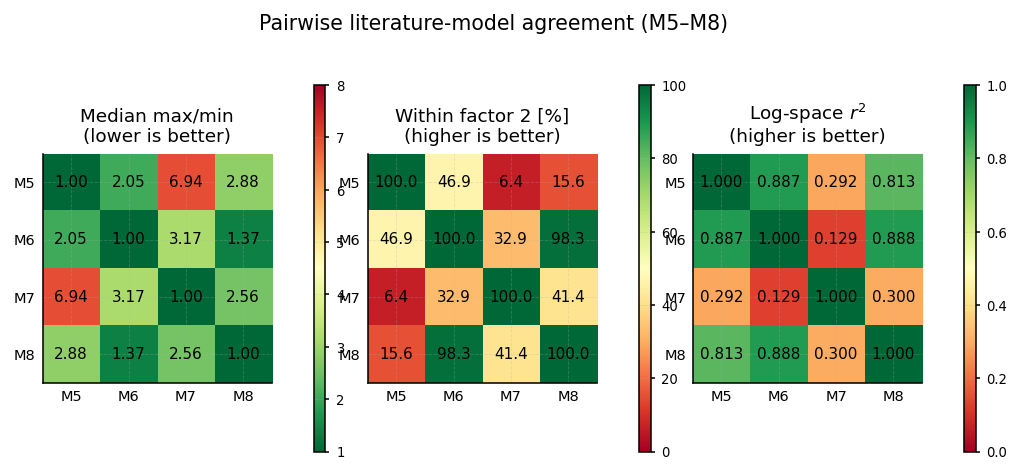

Saved CSVs: stats_73_pairwise_ratio.csv, stats_73_pairwise_fac2.csv, stats_73_pairwise_r2.csv


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.3 — Pairwise literature-model agreement matrix (4 × 4) + report heatmap
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 82)
print('7.3 — PAIRWISE LITERATURE AGREEMENT')
print('=' * 82)
print('Three compact matrices compare every pair of M5–M8.\n')

lit = ['M5', 'M6', 'M7', 'M8']
ratio_mat = pd.DataFrame(index=lit, columns=lit, dtype=float)
fac2_mat  = pd.DataFrame(index=lit, columns=lit, dtype=float)
r2_mat    = pd.DataFrame(index=lit, columns=lit, dtype=float)

for m_a in lit:
    for m_b in lit:
        x = df[f'{m_a}_um']
        y = df[f'{m_b}_um']
        valid = ~x.isna() & ~y.isna() & (x > 0) & (y > 0)
        if valid.sum() < 2:
            continue
        xv, yv = x[valid].values, y[valid].values
        ratios = np.maximum(xv, yv) / np.minimum(xv, yv)
        ratio_mat.loc[m_a, m_b] = np.median(ratios)
        fac2_mat.loc[m_a, m_b]  = 100 * (ratios <= 2).sum() / len(ratios)
        r2_mat.loc[m_a, m_b]    = stats.pearsonr(np.log10(xv), np.log10(yv))[0] ** 2

ratio_mat.to_csv(plot_path('stats_73_pairwise_ratio.csv'))
fac2_mat.to_csv(plot_path('stats_73_pairwise_fac2.csv'))
r2_mat.to_csv(plot_path('stats_73_pairwise_r2.csv'))

_show_table(ratio_mat.astype(float),
            '7.3a — Pairwise median max/min ratio  |  lower = better agreement',
            fmt={c: '{:.2f}' for c in ratio_mat.columns},
            bad_cols=ratio_mat.columns,
            index_width='60px')

_show_table(fac2_mat.astype(float),
            '7.3b — Pairwise % of points within factor-of-2  |  higher = better agreement',
            fmt={c: '{:.1f}' for c in fac2_mat.columns},
            good_cols=fac2_mat.columns,
            index_width='60px')

_show_table(r2_mat.astype(float),
            '7.3c — Pairwise r² on log-transformed values  |  higher = stronger structural agreement',
            fmt={c: '{:.3f}' for c in r2_mat.columns},
            good_cols=r2_mat.columns,
            index_width='60px')

# Report-friendly heatmap: one shared layout with compact colourbars.
fig = plt.figure(figsize=(8.6, 3.4))
gs = fig.add_gridspec(1, 6, width_ratios=[1, 0.05, 1, 0.05, 1, 0.05], wspace=0.35)
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[0, 4])]
caxes = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 3]), fig.add_subplot(gs[0, 5])]

specs = [
    (ratio_mat, 'Median max/min\n(lower is better)', 'RdYlGn_r', 1.0, 8.0, '{:.2f}'),
    (fac2_mat,  'Within factor 2 [%]\n(higher is better)', 'RdYlGn', 0.0, 100.0, '{:.1f}'),
    (r2_mat,    'Log-space $r^2$\n(higher is better)', 'RdYlGn', 0.0, 1.0, '{:.3f}'),
]

for ax, cax, (mat, title, cmap_, vmin, vmax, fmt_hm) in zip(axes, caxes, specs):
    arr = mat.astype(float).values
    im = ax.imshow(arr, cmap=cmap_, vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_xticks(range(len(lit))); ax.set_yticks(range(len(lit)))
    ax.set_xticklabels(lit); ax.set_yticklabels(lit)
    ax.tick_params(length=0)
    for i in range(len(lit)):
        for j in range(len(lit)):
            v = arr[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt_hm.format(v), ha='center', va='center', fontsize=7.8)
    ax.set_title(title, pad=6)
    cb = fig.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=6.8, length=2)

fig.suptitle('Pairwise literature-model agreement (M5–M8)', fontsize=10.5, y=1.03)
save_report_figure(fig, 'stats_73_pairwise_heatmap.png')
plt.show()

print('Saved CSVs: stats_73_pairwise_ratio.csv, stats_73_pairwise_fac2.csv, stats_73_pairwise_r2.csv')


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.4 — Outlier attribution: which literature model is the max or min?
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 82)
print('7.4 — OUTLIER ATTRIBUTION (literature subset M5–M8)')
print('=' * 82)
print('At each sweep point, identify which literature model gives the largest and smallest SMD.\n')

lit_models = ['M5','M6','M7','M8']
lit_arr = df[lit_models].values.astype(float)
lit_arr = np.where(lit_arr > 0, lit_arr, np.nan)

with np.errstate(invalid='ignore'):
    max_idx = np.nanargmax(np.where(np.isnan(lit_arr), -np.inf, lit_arr), axis=1)
    min_idx = np.nanargmin(np.where(np.isnan(lit_arr),  np.inf, lit_arr), axis=1)

valid_rows = np.sum(~np.isnan(lit_arr), axis=1) >= 2
n_ok = int(valid_rows.sum())

rows = []
for i, m in enumerate(lit_models):
    n_model_valid = int(np.sum(~np.isnan(lit_arr[:, i]) & valid_rows))
    times_max = int(np.sum((max_idx == i) & valid_rows))
    times_min = int(np.sum((min_idx == i) & valid_rows))
    rows.append({
        'Model':        m,
        'N compared':   n_model_valid,
        '# times max':  times_max,
        '# times min':  times_min,
        '% times max':  100 * times_max / n_ok if n_ok else np.nan,
        '% times min':  100 * times_min / n_ok if n_ok else np.nan,
    })

outlier = pd.DataFrame(rows).set_index('Model')
outlier.to_csv(plot_path('stats_74_outlier_attribution.csv'))

fmt = {
    'N compared':   '{:,.0f}',
    '# times max':  '{:,.0f}',
    '# times min':  '{:,.0f}',
    '% times max':  '{:.1f}',
    '% times min':  '{:.1f}',
}
_show_table(
    outlier,
    '7.4 — Outlier attribution: which model is usually the high or low prediction?',
    fmt=fmt,
    bad_cols=['% times max', '% times min'],
    index_width='70px'
)

print(f'Saved CSV: {plot_path("stats_74_outlier_attribution.csv")}')
print('\nReading:')
print(f'  • Denominator is {n_ok:,} sweep points where at least 2 literature models are valid.')
print('  • A high % times max means the model is a systematic high-SMD predictor.')
print('  • A high % times min means the model is a systematic low-SMD predictor.')


7.4 — OUTLIER ATTRIBUTION (literature subset M5–M8)
At each sweep point, identify which literature model gives the largest and smallest SMD.



,N compared,# times max,# times min,% times max,% times min
Model,,,,,
M5,"142,800",0,"141,853",0.0,73.9
M6,"153,600",552,"7,529",0.3,3.9
M7,"192,000","156,884","4,371",81.7,2.3
M8,"192,000","34,564","38,247",18.0,19.9


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_74_outlier_attribution.csv

Reading:
  • Denominator is 192,000 sweep points where at least 2 literature models are valid.
  • A high % times max means the model is a systematic high-SMD predictor.
  • A high % times min means the model is a systematic low-SMD predictor.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.5 — Scatter stratified by Π-group regime and by swept geometry/density
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 82)
print('7.5 — SCATTER STRATIFIED BY REGIME')
print('=' * 82)
print('Each table pools the other sweep dimensions and reports literature-subset scatter by bin.\n')

# Weber bin boundaries after Reitz (1978) and Lefebvre & McDonell (2017)
we_bins   = [0, 12, 40, 100, 1000, 1e6]
we_labels = ['We<12\nRayleigh', '12–40\n1st wind', '40–100\n2nd wind',
             '100–1000\natomisation', '>1000\nhigh-We']
df['We_bin'] = pd.cut(df['We'], bins=we_bins, labels=we_labels)

oh_bins   = [0, 0.01, 0.05, 0.1, 1, 10]
oh_labels = ['Oh<0.01', '0.01–0.05', '0.05–0.1', '0.1–1', '>1']
df['Oh_bin'] = pd.cut(df['Oh'], bins=oh_bins, labels=oh_labels)

def _strat_agg(group_col):
    return df.groupby(group_col, observed=True).apply(
        lambda g: pd.Series({
            'N':            int(g['ratio_lit'].count()),
            'Median max/min':    g['ratio_lit'].median(),
            'p95 max/min':       g['ratio_lit'].quantile(0.95),
            'Median σ_log':      g['sigma_log_lit'].median(),
            'Median GSD':        np.exp(g['sigma_log_lit'].median()),
            '% within 2×':       100 * (g['ratio_lit'] <= 2).sum() / max(g['ratio_lit'].count(), 1),
            '% within 3×':       100 * (g['ratio_lit'] <= 3).sum() / max(g['ratio_lit'].count(), 1),
        })
    )

def _display_strat(tbl, caption, csv_name, index_width='140px'):
    tbl.to_csv(plot_path(csv_name))
    fmt = {
        'N': '{:,.0f}',
        'Median max/min': '{:.2f}',
        'p95 max/min': '{:.2f}',
        'Median σ_log': '{:.3f}',
        'Median GSD': '{:.2f}',
        '% within 2×': '{:.1f}',
        '% within 3×': '{:.1f}',
    }
    _show_table(tbl, caption, fmt=fmt,
                bad_cols=['Median max/min', 'p95 max/min', 'Median σ_log', 'Median GSD'],
                good_cols=['% within 2×', '% within 3×'],
                index_width=index_width)
    print(f'Saved CSV: {plot_path(csv_name)}')

_display_strat(_strat_agg('We_bin'),
               '7.5a — Literature scatter by Weber-number regime',
               'stats_75_by_We.csv')

_display_strat(_strat_agg('Oh_bin'),
               '7.5b — Literature scatter by Ohnesorge-number regime',
               'stats_75_by_Oh.csv',
               index_width='90px')

_display_strat(_strat_agg('d0_mm'),
               '7.5c — Literature scatter by nozzle diameter d₀ [mm]',
               'stats_75_by_d0.csv',
               index_width='70px')

_display_strat(_strat_agg('rho_l'),
               '7.5d — Literature scatter by liquid density ρ_l [kg/m³]',
               'stats_75_by_rho_l.csv',
               index_width='80px')

print('\nKey takeaways:')
print('  • We bin: best agreement occurs in the moderate atomisation window; low-We is poor.')
print('  • Oh bin: scatter increases strongly with Oh, showing that viscosity/surface-tension treatment drives disagreement.')
print('  • d₀ and ρ_l bins have weaker effects, so disagreement is not mainly geometry/density controlled.')


7.5 — SCATTER STRATIFIED BY REGIME
Each table pools the other sweep dimensions and reports literature-subset scatter by bin.



,N,Median max/min,p95 max/min,Median σ_log,Median GSD,% within 2×,% within 3×
We_bin,,,,,,,
We<12 Rayleigh,"16,260",11.89,197.84,1.238,3.45,3.7,8.6
12–40 1st wind,"12,000",2.91,10.42,0.532,1.70,32.9,51.5
40–100 2nd wind,"15,860",2.44,8.52,0.388,1.47,39.1,59.6
100–1000 atomisation,"88,100",5.21,18.22,0.624,1.87,6.1,19.4
>1000 high-We,"59,780",9.44,21.78,0.817,2.26,0.0,0.1


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_75_by_We.csv


,N,Median max/min,p95 max/min,Median σ_log,Median GSD,% within 2×,% within 3×
Oh_bin,,,,,,,
Oh<0.01,"53,920",3.51,7.82,0.487,1.63,19.1,36.0
0.01–0.05,"98,000",6.80,16.81,0.727,2.07,6.0,15.0
0.05–0.1,"32,800",14.32,25.20,1.040,2.83,0.0,0.1
0.1–1,"7,280",19.82,34.10,1.180,3.25,0.0,0.0


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_75_by_Oh.csv


,N,Median max/min,p95 max/min,Median σ_log,Median GSD,% within 2×,% within 3×
d0_mm,,,,,,,
0.500000,"48,000",6.43,27.26,0.725,2.06,8.8,17.6
1.000000,"48,000",6.25,22.91,0.711,2.04,8.2,17.5
1.500000,"48,000",6.06,20.39,0.699,2.01,8.3,17.8
2.000000,"48,000",5.91,18.70,0.690,1.99,8.3,18.2


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_75_by_d0.csv


,N,Median max/min,p95 max/min,Median σ_log,Median GSD,% within 2×,% within 3×
rho_l,,,,,,,
800.000000,"64,000",6.33,23.25,0.717,2.05,8.2,18.8
998.000000,"64,000",6.15,22.81,0.706,2.03,8.4,17.7
1300.000000,"64,000",5.98,22.34,0.697,2.01,8.6,16.8


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_75_by_rho_l.csv

Key takeaways:
  • We bin: best agreement occurs in the moderate atomisation window; low-We is poor.
  • Oh bin: scatter increases strongly with Oh, showing that viscosity/surface-tension treatment drives disagreement.
  • d₀ and ρ_l bins have weaker effects, so disagreement is not mainly geometry/density controlled.


---

### 7.6 — Dimensionless driver ranking and high-scatter diagnosis

The previous tables quantify disagreement; this section explains it by asking which dimensionless variables are most strongly associated with literature-model scatter.

The analysis uses the independent literature subset only (M5–M8). This keeps the main conclusion free from bias introduced by the Chideme/dissertation correlations M1–M4.


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.6 — Dimensionless driver ranking and high-scatter diagnosis
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 82)
print('7.6 — DIMENSIONLESS DRIVERS OF LITERATURE-MODEL DISAGREEMENT')
print('=' * 82)
print('Target variable: σ_log_lit, the pointwise log-scatter across M5–M8 only.\n')

# Work only with rows where literature-subset scatter is defined and the π-groups are positive.
driver_cols = ['sigma_log_lit', 'ratio_lit', 'We', 'Re', 'Oh',
               'GLR', 'mu_l_mPa', 'sigma_mN', 'd0_mm', 'rho_l'] + literature_cols
valid_driver = df[driver_cols].dropna(subset=['sigma_log_lit', 'ratio_lit', 'We', 'Re', 'Oh']).copy()
valid_driver = valid_driver[(valid_driver['We'] > 0) &
                            (valid_driver['Re'] > 0) &
                            (valid_driver['Oh'] > 0) &
                            (valid_driver['ratio_lit'] > 0)]

predictor_defs = {
    'log10(We)':       np.log10(valid_driver['We']),
    'log10(Re)':       np.log10(valid_driver['Re']),
    'log10(Oh)':       np.log10(valid_driver['Oh']),
    'log10(GLR)':      np.log10(valid_driver['GLR']),
    'log10(mu_l)':     np.log10(valid_driver['mu_l_mPa']),
    'log10(sigma)':    np.log10(valid_driver['sigma_mN']),
    'log10(d0)':       np.log10(valid_driver['d0_mm']),
    'rho_l':           valid_driver['rho_l'],
}

rows = []
for name, x in predictor_defs.items():
    rho_s, p_val = stats.spearmanr(x, valid_driver['sigma_log_lit'], nan_policy='omit')
    rows.append({
        'Predictor': name,
        'Spearman ρ': rho_s,
        '|ρ|': abs(rho_s),
        'p-value': p_val,
    })

driver_rank = (pd.DataFrame(rows)
               .sort_values('|ρ|', ascending=False)
               .set_index('Predictor'))

driver_rank.to_csv(plot_path('stats_76_dimensionless_driver_ranking.csv'))
fmt = {'Spearman ρ': '{:+.3f}', '|ρ|': '{:.3f}', 'p-value': '{:.1e}'}
_show_table(
    driver_rank,
    '7.6a — Variables ranked by monotonic association with literature scatter',
    fmt=fmt,
    bad_cols=['|ρ|'],
    index_width='120px'
)
print(f'Saved CSV: {plot_path("stats_76_dimensionless_driver_ranking.csv")}')

# Compare low-scatter and high-scatter regions directly.
q25 = valid_driver['sigma_log_lit'].quantile(0.25)
q95 = valid_driver['sigma_log_lit'].quantile(0.95)
low_scatter  = valid_driver[valid_driver['sigma_log_lit'] <= q25].copy()
high_scatter = valid_driver[valid_driver['sigma_log_lit'] >= q95].copy()

for g in [low_scatter, high_scatter]:
    g['max_model'] = g[literature_cols].idxmax(axis=1)
    g['min_model'] = g[literature_cols].idxmin(axis=1)

def _dominant(series):
    vc = series.value_counts(normalize=True)
    if len(vc) == 0:
        return '—', np.nan
    return vc.index[0], 100 * vc.iloc[0]

def _scatter_region_summary(name, g):
    max_model, max_share = _dominant(g['max_model'])
    min_model, min_share = _dominant(g['min_model'])
    return {
        'Region': name,
        'N': len(g),
        'median σ_log_lit': g['sigma_log_lit'].median(),
        'median GSD': np.exp(g['sigma_log_lit'].median()),
        'median max/min': g['ratio_lit'].median(),
        'median We': g['We'].median(),
        'median Re': g['Re'].median(),
        'median Oh': g['Oh'].median(),
        'median GLR': g['GLR'].median(),
        'median μ_l (mPa·s)': g['mu_l_mPa'].median(),
        'median σ (mN/m)': g['sigma_mN'].median(),
        'dominant high model': max_model,
        '% high model share': max_share,
        'dominant low model': min_model,
        '% low model share': min_share,
    }

scatter_contrast = pd.DataFrame([
    _scatter_region_summary('Lowest-scatter quartile', low_scatter),
    _scatter_region_summary('Highest-scatter 5%', high_scatter),
]).set_index('Region')
scatter_contrast.to_csv(plot_path('stats_76_low_vs_high_scatter_regions.csv'))

# Split the wide contrast table into readable pieces.
contrast_metrics = scatter_contrast[[
    'N', 'median σ_log_lit', 'median GSD', 'median max/min'
]]
contrast_conditions = scatter_contrast[[
    'median We', 'median Re', 'median Oh', 'median GLR',
    'median μ_l (mPa·s)', 'median σ (mN/m)'
]]
contrast_extremes = scatter_contrast[[
    'dominant high model', '% high model share',
    'dominant low model', '% low model share'
]]

fmt_metrics = {
    'N': '{:,.0f}',
    'median σ_log_lit': '{:.3f}',
    'median GSD': '{:.2f}',
    'median max/min': '{:.2f}',
}
_show_table(
    contrast_metrics,
    '7.6b — Low-scatter vs high-scatter regions: scatter metrics',
    fmt=fmt_metrics,
    bad_cols=['median σ_log_lit', 'median GSD', 'median max/min'],
    index_width='170px'
)

fmt_cond = {
    'median We': '{:,.1f}',
    'median Re': '{:,.1f}',
    'median Oh': '{:.4f}',
    'median GLR': '{:.3f}',
    'median μ_l (mPa·s)': '{:.2f}',
    'median σ (mN/m)': '{:.1f}',
}
_show_table(
    contrast_conditions,
    '7.6c — Low-scatter vs high-scatter regions: operating-space shift',
    fmt=fmt_cond,
    index_width='170px'
)

fmt_ext = {'% high model share': '{:.1f}', '% low model share': '{:.1f}'}
_show_table(
    contrast_extremes,
    '7.6d — Low-scatter vs high-scatter regions: dominant extreme models',
    fmt=fmt_ext,
    bad_cols=['% high model share', '% low model share'],
    index_width='170px'
)
print(f'Saved CSV: {plot_path("stats_76_low_vs_high_scatter_regions.csv")}')

strongest = driver_rank.index[0]
sign = 'increases' if driver_rank.iloc[0]['Spearman ρ'] > 0 else 'decreases'
print('\nInterpretation:')
print(f'  • The strongest monotonic driver is {strongest}; σ_log_lit generally {sign} as this variable increases.')
print('  • If log10(Oh) ranks near the top, the disagreement is mainly controlled by viscosity/surface-tension physics.')
print('  • The contrast tables show what changes physically between low-scatter and high-scatter operating regions.')


7.6 — DIMENSIONLESS DRIVERS OF LITERATURE-MODEL DISAGREEMENT
Target variable: σ_log_lit, the pointwise log-scatter across M5–M8 only.



,Spearman ρ,|ρ|,p-value
Predictor,,,
log10(Oh),+0.721,0.721,0.0e+00
log10(mu_l),+0.710,0.710,0.0e+00
log10(Re),-0.609,0.609,0.0e+00
log10(GLR),+0.228,0.228,0.0e+00
log10(We),+0.211,0.211,0.0e+00
log10(sigma),-0.204,0.204,0.0e+00
log10(d0),-0.038,0.038,2.5e-62
rho_l,-0.019,0.019,1.1e-16


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_76_dimensionless_driver_ranking.csv


,N,median σ_log_lit,median GSD,median max/min
Region,,,,
Lowest-scatter quartile,"48,000",0.370,1.45,2.49
Highest-scatter 5%,"9,601",1.900,6.69,44.74


,median We,median Re,median Oh,median GLR,median μ_l (mPa·s),median σ (mN/m)
Region,,,,,,
Lowest-scatter quartile,170.1,205.0,0.0082,0.776,1.88,54.2
Highest-scatter 5%,0.4,52.8,0.0436,0.089,9.09,40.8


,dominant high model,% high model share,dominant low model,% low model share
Region,,,,
Lowest-scatter quartile,M8,49.8,M5,58.6
Highest-scatter 5%,M7,100.0,M8,84.8


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_76_low_vs_high_scatter_regions.csv

Interpretation:
  • The strongest monotonic driver is log10(Oh); σ_log_lit generally increases as this variable increases.
  • If log10(Oh) ranks near the top, the disagreement is mainly controlled by viscosity/surface-tension physics.
  • The contrast tables show what changes physically between low-scatter and high-scatter operating regions.


---

### 7.7 — Engineering interpretation of scatter regions

The table below converts the statistical metrics into design meaning. The aim is to avoid reporting only “large” or “small” scatter, and instead state how confidently the correlations can be used in each operating region.


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# 7.7 — Engineering interpretation table
# Converts scatter statistics into design/risk statements.
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 82)
print('7.7 — ENGINEERING INTERPRETATION OF MODEL RELIABILITY')
print('=' * 82)

# Ensure regime bins exist even if this cell is run independently after Section 6.
if 'We_bin' not in df.columns:
    we_bins   = [0, 12, 40, 100, 1000, 1e6]
    we_labels = ['We<12 (Rayleigh)', '12–40 (1st wind)', '40–100 (2nd wind)',
                 '100–1000 (atomisation)', '>1000 (high-We)']
    df['We_bin'] = pd.cut(df['We'], bins=we_bins, labels=we_labels)
if 'Oh_bin' not in df.columns:
    oh_bins   = [0, 0.01, 0.05, 0.1, 1, 10]
    oh_labels = ['Oh<0.01', '0.01–0.05', '0.05–0.1', '0.1–1', '>1']
    df['Oh_bin'] = pd.cut(df['Oh'], bins=oh_bins, labels=oh_labels)

analysis_regions = {
    'Best-agreement\natomisation window': (
        (df['We'] >= 40) & (df['We'] <= 100) & (df['Oh'] < 0.01),
        'Use correlations as a cross-check; disagreement is comparatively low.'
    ),
    'Low-We / weak\ngas-breakup region': (
        (df['We'] < 12),
        'High extrapolation risk; correlations do not encode the same breakup regime.'
    ),
    'High-Oh / viscous\nproperty-sensitive region': (
        (df['Oh'] >= 0.05),
        'Predictions become strongly model-dependent because viscosity terms differ.'
    ),
    'High-We\nextrapolation region': (
        (df['We'] > 1000),
        'Agreement worsens again; avoid assuming high gas momentum guarantees convergence.'
    ),
    'Baseline water-like\nreliability region': (
        (df['Oh'] < 0.01) & (df['We'] >= 40) & (df['We'] <= 1000),
        'Most representative of low-viscosity water-like atomisation conditions.'
    ),
}

def _region_metrics(name, mask, implication):
    g = df[mask & df['ratio_lit'].notna() & df['sigma_log_lit'].notna()].copy()
    if len(g) == 0:
        return {
            'Region': name, 'N': 0, 'median σ_log_lit': np.nan,
            'median GSD': np.nan, 'median max/min': np.nan,
            '% within 2×': np.nan, '% within 3×': np.nan,
            'Interpretation': implication,
        }
    return {
        'Region': name,
        'N': len(g),
        'median σ_log_lit': g['sigma_log_lit'].median(),
        'median GSD': np.exp(g['sigma_log_lit'].median()),
        'median max/min': g['ratio_lit'].median(),
        '% within 2×': 100 * (g['ratio_lit'] <= 2).mean(),
        '% within 3×': 100 * (g['ratio_lit'] <= 3).mean(),
        'Interpretation': implication,
    }

engineering_table = pd.DataFrame([
    _region_metrics(name, mask, implication)
    for name, (mask, implication) in analysis_regions.items()
]).set_index('Region')
engineering_table.to_csv(plot_path('stats_77_engineering_interpretation.csv'))

# Split into a numeric table and a wrapped interpretation table.
engineering_metrics = engineering_table.drop(columns=['Interpretation'])
engineering_notes = engineering_table[['Interpretation']]

fmt = {
    'N': '{:,.0f}',
    'median σ_log_lit': '{:.3f}',
    'median GSD': '{:.2f}',
    'median max/min': '{:.2f}',
    '% within 2×': '{:.1f}',
    '% within 3×': '{:.1f}',
}
_show_table(
    engineering_metrics,
    '7.7a — Engineering reliability regions: numeric scatter metrics',
    fmt=fmt,
    bad_cols=['median σ_log_lit', 'median GSD', 'median max/min'],
    good_cols=['% within 2×', '% within 3×'],
    index_width='190px'
)

_show_table(
    engineering_notes,
    '7.7b — Engineering reliability regions: design interpretation',
    fmt={'Interpretation': '{}'},
    left_cols=['Interpretation'],
    index_width='190px'
)
print(f'Saved CSV: {plot_path("stats_77_engineering_interpretation.csv")}')

print('\nReport-ready conclusion sentence:')
print('  The independent literature correlations agree best in moderate-We, low-Oh')
print('  atomisation conditions, but diverge in low-We and high-Oh regions, showing')
print('  that model disagreement is controlled mainly by breakup-regime limits and')
print('  the treatment of viscosity/surface-tension physics rather than by density')
print('  or nozzle diameter alone.')


7.7 — ENGINEERING INTERPRETATION OF MODEL RELIABILITY


,N,median σ_log_lit,median GSD,median max/min,% within 2×,% within 3×
Region,,,,,,
Best-agreement atomisation window,"4,244",0.141,1.15,1.34,87.5,100.0
Low-We / weak gas-breakup region,"16,260",1.238,3.45,11.89,3.7,8.6
High-Oh / viscous property-sensitive region,"40,080",1.063,2.90,15.05,0.0,0.1
High-We extrapolation region,"59,780",0.817,2.26,9.44,0.0,0.1
Baseline water-like reliability region,"28,103",0.393,1.48,2.85,27.3,56.2


,Interpretation
Region,
Best-agreement atomisation window,Use correlations as a cross-check; disagreement is comparatively low.
Low-We / weak gas-breakup region,High extrapolation risk; correlations do not encode the same breakup regime.
High-Oh / viscous property-sensitive region,Predictions become strongly model-dependent because viscosity terms differ.
High-We extrapolation region,Agreement worsens again; avoid assuming high gas momentum guarantees convergence.
Baseline water-like reliability region,Most representative of low-viscosity water-like atomisation conditions.


Saved CSV: C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\stats_77_engineering_interpretation.csv

Report-ready conclusion sentence:
  The independent literature correlations agree best in moderate-We, low-Oh
  atomisation conditions, but diverge in low-We and high-Oh regions, showing
  that model disagreement is controlled mainly by breakup-regime limits and
  the treatment of viscosity/surface-tension physics rather than by density
  or nozzle diameter alone.


---

## Section 8 — Visualisations

The plots in this section are formatted for direct insertion into Word. The saved versions are exported as 300 dpi PNG files to the `plots_word_ready` folder. Multi-panel figures use explicit colourbar axes and shorter axis labels to avoid overlap when resized in the report.

### Plot 1 — $SMD$ vs $GLR$ at baseline water properties

All eight models plotted against $GLR$, with viscosity and surface tension fixed at water values, nozzle diameter at 1 mm, and liquid density at 998 kg/m³. Every model should trend downward (more gas energy gives finer spray). The y-axis is logarithmic so the vertical spacing between the curves — which is the point-by-point disagreement between models — is visible at a glance.


Plotting 40 points at μ_l = 1.000 mPa·s, σ = 73.0 mN/m, d_0 = 1.0 mm, ρ_l = 998 kg/m³


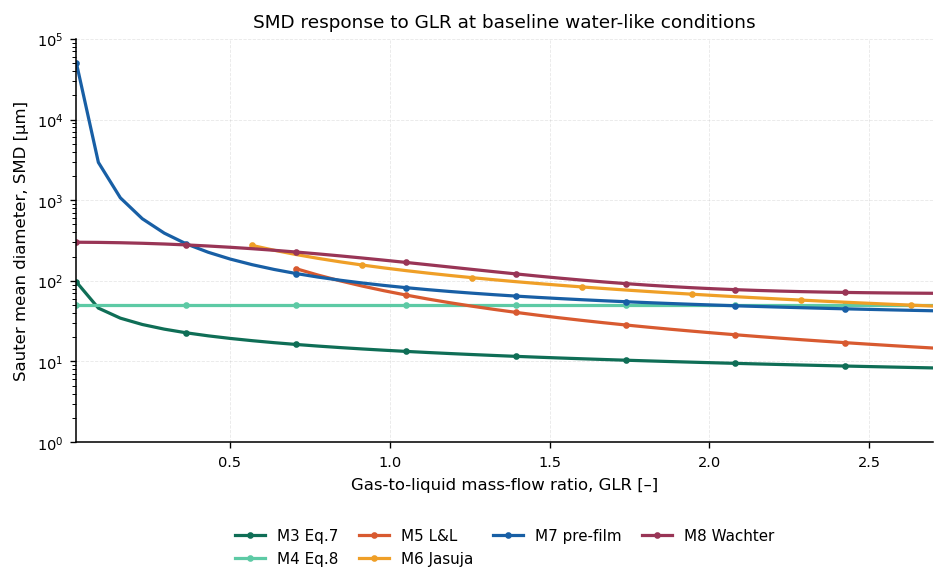

Plot 1 saved.


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — SMD vs GLR at baseline fluid properties + baseline geometry
# Fixed slice: mu = 1 mPa·s, sigma = 72.8 mN/m, d_0 = 1 mm, rho_l = 998 kg/m³
# ─────────────────────────────────────────────────────────────────────────────

mu_nearest    = mu_range[np.argmin(np.abs(mu_range - 1.003e-3))]
sigma_nearest = sigma_range[np.argmin(np.abs(sigma_range - 72.8e-3))]
d0_nearest    = d0_range[np.argmin(np.abs(d0_range - d0_baseline))]
rho_l_nearest = rho_l_range[np.argmin(np.abs(rho_l_range - rho_l_baseline))]

mask = (np.isclose(df['mu_l'],  mu_nearest,    rtol=1e-3) &
        np.isclose(df['sigma'], sigma_nearest, rtol=1e-3) &
        np.isclose(df['d0'],    d0_nearest,    rtol=1e-3) &
        np.isclose(df['rho_l'], rho_l_nearest, rtol=1e-3))
df_slice = df[mask].sort_values('GLR')

print(f'Plotting {len(df_slice)} points at μ_l = {mu_nearest*1e3:.3f} mPa·s,'
      f' σ = {sigma_nearest*1e3:.1f} mN/m, d_0 = {d0_nearest*1e3:.1f} mm,'
      f' ρ_l = {rho_l_nearest:.0f} kg/m³')

fig, ax = plt.subplots(figsize=(7.2, 4.5))
for m in model_cols:
    y = df_slice[f'{m}_um']
    valid = ~y.isna()
    if valid.sum() > 0:
        ax.plot(df_slice['GLR'][valid], y[valid],
                color=colours[m], label=MODEL_SHORT_LABELS[m],
                linewidth=1.65, marker='o', markersize=2.4, markevery=5)

ax.set_xlabel('Gas-to-liquid mass-flow ratio, GLR [–]')
ax.set_ylabel('Sauter mean diameter, SMD [μm]')
ax.set_title('SMD response to GLR at baseline water-like conditions')
ax.set_xlim(GLR_range[0], GLR_range[-1])
ax.set_yscale('log')
ax.set_ylim(1, 1e5)
format_log_axis(ax, 'y')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4,
          frameon=False, columnspacing=1.3, handlelength=2.0)

fig.subplots_adjust(bottom=0.26, top=0.90, left=0.12, right=0.97)
save_report_figure(fig, 'plot1_SMD_vs_GLR.png')
plt.show()
print('Plot 1 saved.')


### Plot 2 — $SMD/d_0$ vs Weber number

The same predictions as Plot 1 but shown dimensionlessly. $SMD$ is divided by $d_0$, and the x-axis is the Weber number instead of $GLR$. Both axes are logarithmic.

If every model encoded the same physics, these curves would overlap. The vertical gap between curves at any given $We$ is the real structural disagreement between models — the part that cannot be explained by the operating point being different. Colour is viscosity, so the vertical stacking of each model's own curves shows how strongly that model depends on viscosity.


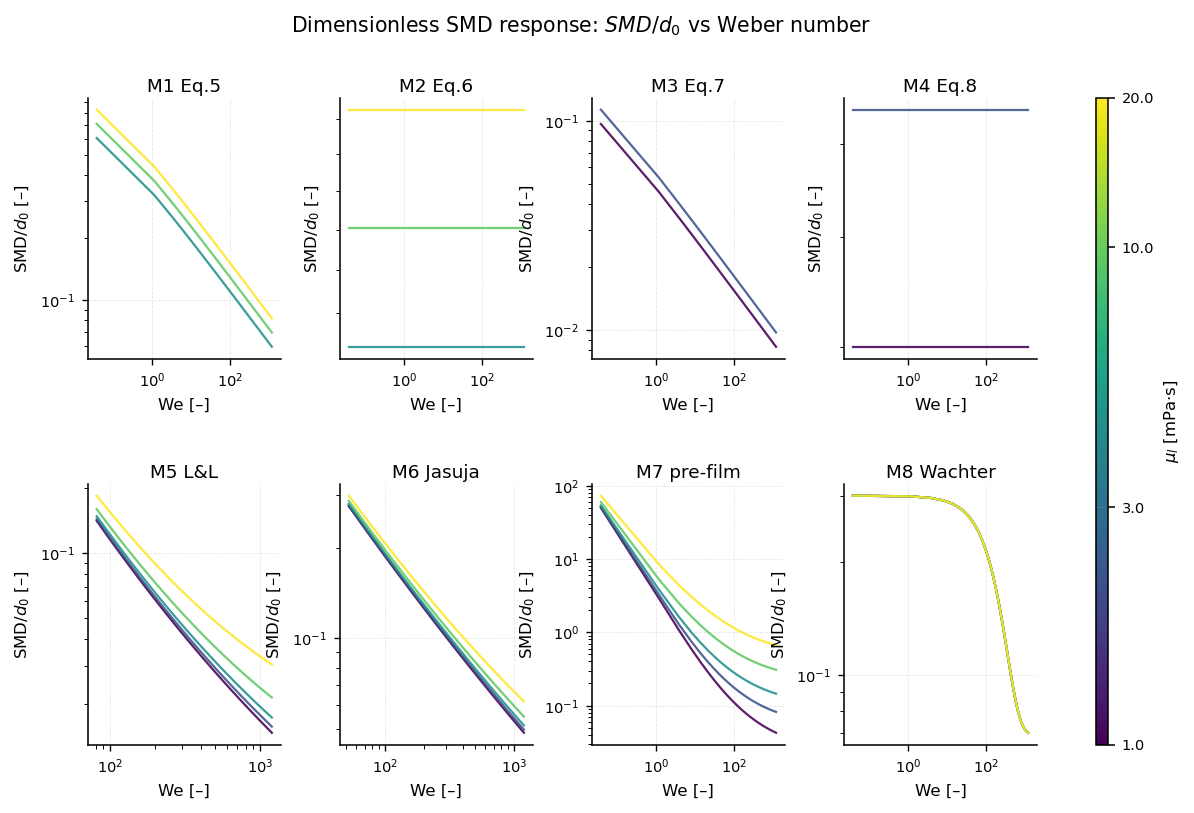

Plot 2 saved.


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — SMD/d₀ vs Weber number (dimensionless)
# Sliced at baseline d_0 = 1 mm and baseline rho_l (water); colour = viscosity.
# ─────────────────────────────────────────────────────────────────────────────

mu_plot_vals = np.logspace(np.log10(1e-3), np.log10(20e-3), 5)
mu_nearest_5 = [mu_range[np.argmin(np.abs(mu_range - mv))] for mv in mu_plot_vals]

sigma_nearest = sigma_range[np.argmin(np.abs(sigma_range - 72.8e-3))]
d0_nearest    = d0_range[np.argmin(np.abs(d0_range - d0_baseline))]
rho_l_nearest = rho_l_range[np.argmin(np.abs(rho_l_range - rho_l_baseline))]

fig = plt.figure(figsize=(9.4, 6.0))
gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 1, 0.06], wspace=0.38, hspace=0.48)
axes = [fig.add_subplot(gs[i // 4, i % 4]) for i in range(8)]
cax = fig.add_subplot(gs[:, 4])

cmap   = cm.get_cmap('viridis', len(mu_nearest_5))
norm_c = Normalize(vmin=np.log10(1e-3), vmax=np.log10(20e-3))

for idx, m in enumerate(model_cols):
    ax = axes[idx]
    col = f'{m}_over_d0'

    for mu_v in mu_nearest_5:
        mask = (np.isclose(df['mu_l'],  mu_v,           rtol=1e-3) &
                np.isclose(df['sigma'], sigma_nearest,  rtol=1e-3) &
                np.isclose(df['d0'],    d0_nearest,     rtol=1e-3) &
                np.isclose(df['rho_l'], rho_l_nearest,  rtol=1e-3))
        sub = df[mask].sort_values('We')
        y = sub[col].values
        x = sub['We'].values
        valid = ~np.isnan(y) & (y > 0) & (x > 0)
        if valid.sum() > 0:
            ax.plot(x[valid], y[valid],
                    color=cmap(norm_c(np.log10(mu_v))),
                    linewidth=1.15, alpha=0.88)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(MODEL_SHORT_LABELS[m], pad=3)
    ax.set_xlabel('We [–]')
    ax.set_ylabel('SMD/$d_0$ [–]')
    format_log_axis(ax, 'both')

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm_c)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('$\mu_l$ [mPa·s]')
tick_vals = np.log10([1e-3, 3e-3, 1e-2, 2e-2])
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f'{10**v*1e3:.1f}' for v in tick_vals])

fig.suptitle('Dimensionless SMD response: $SMD/d_0$ vs Weber number', fontsize=10.5, y=0.98)
save_report_figure(fig, 'plot2_SMDd0_vs_We.png')
plt.show()
print('Plot 2 saved.')


### Plot 3 — $We$–$Oh$ map coloured by inter-model scatter

Every sweep point at a fixed $GLR$ is plotted as a dot in this plane, coloured by how much the four literature models disagree at that point.

Two panels:
- **Left:** colour is the log-scatter $\sigma_{\log}$ across M5–M8.
- **Right:** colour is $\log_{10}(\text{max}/\text{min})$, the ratio of the biggest to smallest prediction.

Green means the four literature models agree; red means they diverge. Dotted vertical lines mark the standard breakup-regime boundaries.


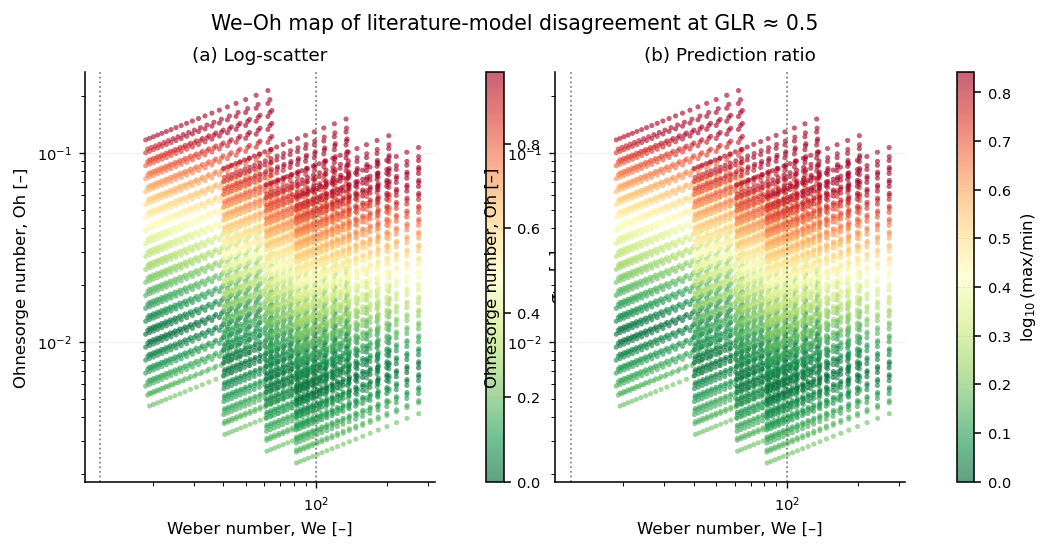

Plot 3 saved.


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — We–Oh parameter-space map at fixed GLR, coloured by literature-subset
# scatter. Left panel: σ_log. Right panel: max/min ratio.
# ─────────────────────────────────────────────────────────────────────────────

GLR_fixed = 0.5
mask_glr  = np.isclose(df['GLR'], GLR_range[np.argmin(np.abs(GLR_range - GLR_fixed))], rtol=1e-3)
sub = df[mask_glr].copy()

fig = plt.figure(figsize=(8.2, 3.8))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 0.05, 1, 0.05], wspace=0.28)
ax1 = fig.add_subplot(gs[0, 0]); cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2]); cax2 = fig.add_subplot(gs[0, 3])

sc1 = ax1.scatter(sub['We'], sub['Oh'],
                  c=sub['sigma_log_lit'], cmap='RdYlGn_r',
                  norm=Normalize(vmin=0, vmax=sub['sigma_log_lit'].quantile(0.95)),
                  s=7, alpha=0.62, edgecolors='none', rasterized=True)
cbar1 = fig.colorbar(sc1, cax=cax1)
cbar1.set_label('$\sigma_{log}$ [–]')
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel('Weber number, We [–]')
ax1.set_ylabel('Ohnesorge number, Oh [–]')
ax1.set_title('(a) Log-scatter')

sc2 = ax2.scatter(sub['We'], sub['Oh'],
                  c=np.log10(sub['ratio_lit']), cmap='RdYlGn_r',
                  norm=Normalize(vmin=0, vmax=np.log10(sub['ratio_lit'].quantile(0.95))),
                  s=7, alpha=0.62, edgecolors='none', rasterized=True)
cbar2 = fig.colorbar(sc2, cax=cax2)
cbar2.set_label('$\log_{10}$(max/min)')
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel('Weber number, We [–]')
ax2.set_ylabel('Ohnesorge number, Oh [–]')
ax2.set_title('(b) Prediction ratio')

for ax in (ax1, ax2):
    for we_b, lbl in [(12, 'We=12'), (100, 'We=100')]:
        ax.axvline(we_b, color='0.25', ls=':', lw=0.9, alpha=0.65)
    format_log_axis(ax, 'both')

fig.suptitle(f'We–Oh map of literature-model disagreement at GLR ≈ {GLR_fixed}', fontsize=10.5, y=0.99)
save_report_figure(fig, 'plot3_We_Oh_scatter.png')
plt.show()
print('Plot 3 saved.')


### Plot 4 — How each model responds to viscosity and surface tension

The original 16-panel sensitivity figure has been split into two report-friendly figures: Plot 4A for viscosity sensitivity and Plot 4B for surface-tension sensitivity. This makes the panels readable after pasting into Word.

This plot answers two questions: (1) which fluid property does each model actually respond to, and (2) do the models even agree on the *direction* of the effect? A flat line means the model is insensitive to that parameter; a steep line means the model has a strong response.


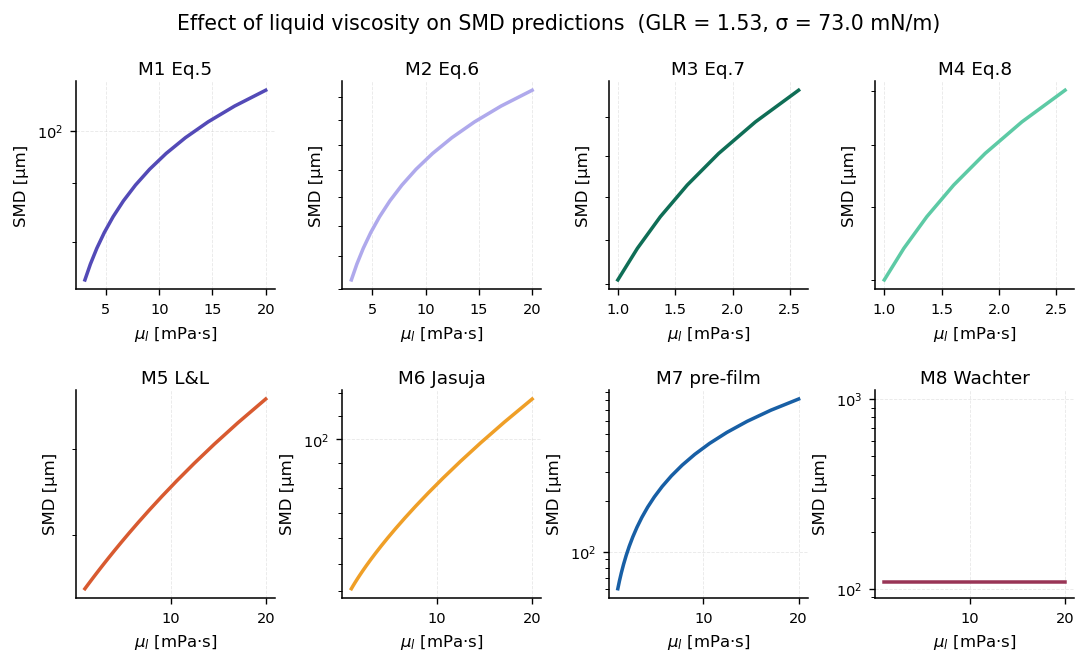

Plot 4A saved.


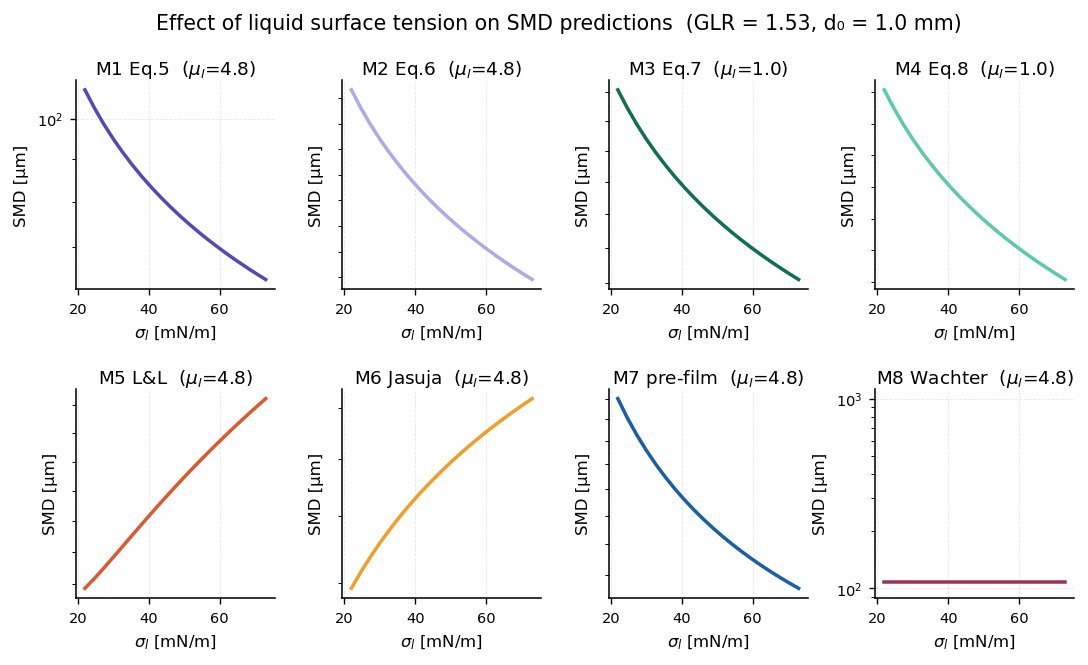

Plot 4B saved.


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — SMD sensitivity to viscosity and surface tension.
# Split into two report-friendly figures instead of one crowded 16-panel figure.
# GLR = 1.5, d_0 = 1 mm, rho_l = 998 kg/m³.
# ─────────────────────────────────────────────────────────────────────────────

GLR_fixed   = 1.5
GLR_nearest = GLR_range[np.argmin(np.abs(GLR_range - GLR_fixed))]
d0_nearest    = d0_range[np.argmin(np.abs(d0_range - d0_baseline))]
rho_l_nearest = rho_l_range[np.argmin(np.abs(rho_l_range - rho_l_baseline))]

sigma_ref = sigma_range[np.argmin(np.abs(sigma_range - 72.8e-3))]
mask_visc = (np.isclose(df['GLR'],   GLR_nearest,  rtol=1e-3) &
             np.isclose(df['sigma'], sigma_ref,    rtol=1e-3) &
             np.isclose(df['d0'],    d0_nearest,   rtol=1e-3) &
             np.isclose(df['rho_l'], rho_l_nearest, rtol=1e-3))
df_visc = df[mask_visc].sort_values('mu_l')

mu_viscous    = mu_range[np.argmin(np.abs(mu_range - 5e-3))]
mu_nonviscous = mu_range[np.argmin(np.abs(mu_range - 1.003e-3))]

mask_surf_visc = (np.isclose(df['GLR'],   GLR_nearest,    rtol=1e-3) &
                  np.isclose(df['mu_l'],  mu_viscous,     rtol=1e-3) &
                  np.isclose(df['d0'],    d0_nearest,     rtol=1e-3) &
                  np.isclose(df['rho_l'], rho_l_nearest,  rtol=1e-3))
df_surf_visc = df[mask_surf_visc].sort_values('sigma')

mask_surf_nv = (np.isclose(df['GLR'],   GLR_nearest,    rtol=1e-3) &
                np.isclose(df['mu_l'],  mu_nonviscous,  rtol=1e-3) &
                np.isclose(df['d0'],    d0_nearest,     rtol=1e-3) &
                np.isclose(df['rho_l'], rho_l_nearest,  rtol=1e-3))
df_surf_nv = df[mask_surf_nv].sort_values('sigma')

# ── Plot 4A: viscosity sensitivity ─────────────────────────────────────────
figA = plt.figure(figsize=(9.2, 4.8))
gsA = figA.add_gridspec(2, 4, wspace=0.34, hspace=0.48)
axesA = [figA.add_subplot(gsA[i // 4, i % 4]) for i in range(8)]

for ax, m in zip(axesA, model_cols):
    y = df_visc[f'{m}_um']
    x = df_visc['mu_l_mPa']
    valid = ~y.isna() & (y > 0)
    if valid.sum() > 0:
        ax.plot(x[valid], y[valid], color=colours[m], linewidth=1.8)
    else:
        ax.text(0.5, 0.5, 'No valid\nvalues', transform=ax.transAxes,
                ha='center', va='center', fontsize=7.5, color='0.45')
    ax.set_xlabel('$\mu_l$ [mPa·s]')
    ax.set_ylabel('SMD [μm]')
    ax.set_title(MODEL_SHORT_LABELS[m], pad=3)
    ax.set_yscale('log')
    format_log_axis(ax, 'y')

figA.suptitle(f'Effect of liquid viscosity on SMD predictions  (GLR = {GLR_nearest:.2f}, σ = {sigma_ref*1e3:.1f} mN/m)',
              fontsize=10.5, y=0.98)
save_report_figure(figA, 'plot4A_viscosity_sensitivity.png')
plt.show()
print('Plot 4A saved.')

# ── Plot 4B: surface-tension sensitivity ───────────────────────────────────
figB = plt.figure(figsize=(9.2, 4.8))
gsB = figB.add_gridspec(2, 4, wspace=0.34, hspace=0.48)
axesB = [figB.add_subplot(gsB[i // 4, i % 4]) for i in range(8)]

for ax, m in zip(axesB, model_cols):
    if m in ['M3', 'M4']:
        df_surf_use, mu_label = df_surf_nv, mu_nonviscous
    else:
        df_surf_use, mu_label = df_surf_visc, mu_viscous
    y = df_surf_use[f'{m}_um']
    x = df_surf_use['sigma_mN']
    valid = ~y.isna() & (y > 0)
    if valid.sum() > 0:
        ax.plot(x[valid], y[valid], color=colours[m], linewidth=1.8)
    else:
        ax.text(0.5, 0.5, 'No valid\nvalues', transform=ax.transAxes,
                ha='center', va='center', fontsize=7.5, color='0.45')
    ax.set_xlabel('$\sigma_l$ [mN/m]')
    ax.set_ylabel('SMD [μm]')
    ax.set_title(f'{MODEL_SHORT_LABELS[m]}  ($\mu_l$={mu_label*1e3:.1f})', pad=3)
    ax.set_yscale('log')
    format_log_axis(ax, 'y')

figB.suptitle(f'Effect of liquid surface tension on SMD predictions  (GLR = {GLR_nearest:.2f}, d₀ = {d0_nearest*1e3:.1f} mm)',
              fontsize=10.5, y=0.98)
save_report_figure(figB, 'plot4B_surface_tension_sensitivity.png')
plt.show()
print('Plot 4B saved.')


### Plot 5 — Inter-model scatter $\sigma_{\log}$ vs $GLR$

$\sigma_{\log}$ plotted against $GLR$ at five viscosity levels. Two line styles per viscosity:

- **Solid:** $\sigma_{\log}$ across **all eight** models (the full set)
- **Dashed:** $\sigma_{\log}$ across the **literature subset** (M5–M8 only)

The gap between the solid and dashed lines shows how much of the apparent "inter-model scatter" is actually being introduced by the Chideme models. Where the dashed line sits well below the solid one, the published literature is converging and the apparent disagreement is coming from M1–M4 being outliers.


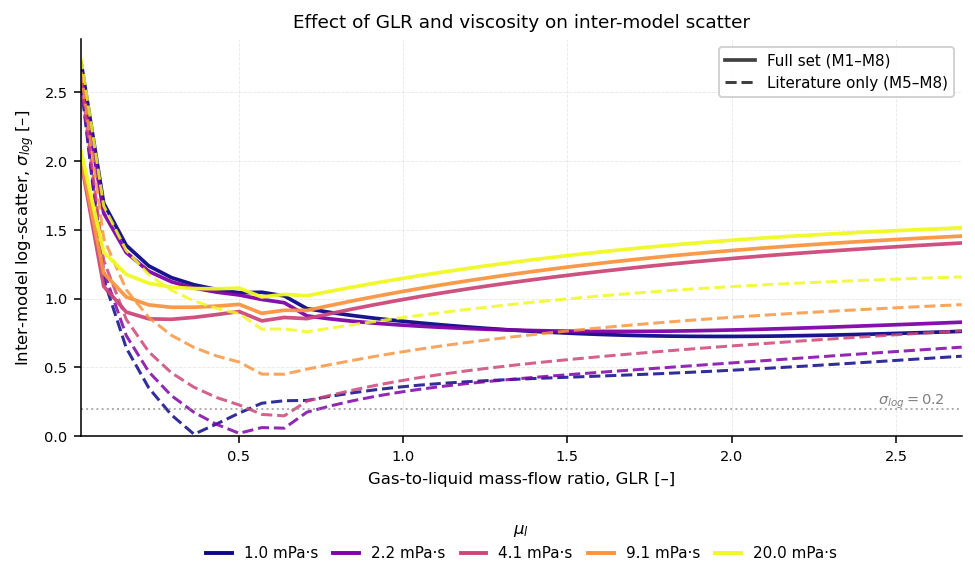

Plot 5 saved.


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5 — σ_log vs GLR, literature subset (dashed) overlaid on full set (solid)
# One line pair per viscosity level; σ, d_0, rho_l fixed at baselines.
# ─────────────────────────────────────────────────────────────────────────────

sigma_ref     = sigma_range[np.argmin(np.abs(sigma_range - 72.8e-3))]
d0_nearest    = d0_range[np.argmin(np.abs(d0_range - d0_baseline))]
rho_l_nearest = rho_l_range[np.argmin(np.abs(rho_l_range - rho_l_baseline))]

mu_plot_5   = np.logspace(np.log10(1e-3), np.log10(20e-3), 5)
mu_nearest5 = [mu_range[np.argmin(np.abs(mu_range - mv))] for mv in mu_plot_5]
cmap5       = cm.get_cmap('plasma', len(mu_nearest5))

fig, ax = plt.subplots(figsize=(7.4, 4.5))

for i_mu, mu_v in enumerate(mu_nearest5):
    mask = (np.isclose(df['mu_l'],  mu_v,           rtol=1e-3) &
            np.isclose(df['sigma'], sigma_ref,      rtol=1e-3) &
            np.isclose(df['d0'],    d0_nearest,     rtol=1e-3) &
            np.isclose(df['rho_l'], rho_l_nearest,  rtol=1e-3))
    sub  = df[mask].sort_values('GLR')
    col  = cmap5(i_mu / len(mu_nearest5))
    ax.plot(sub['GLR'], sub['sigma_log_full'], color=col, linewidth=1.9, alpha=0.95)
    ax.plot(sub['GLR'], sub['sigma_log_lit'],  color=col, linewidth=1.55, alpha=0.85,
            linestyle='--')

from matplotlib.lines import Line2D
style_handles = [Line2D([0],[0], color='0.25', lw=1.9, linestyle='-',  label='Full set (M1–M8)'),
                 Line2D([0],[0], color='0.25', lw=1.55, linestyle='--', label='Literature only (M5–M8)')]
mu_handles = [Line2D([0],[0], color=cmap5(i / len(mu_nearest5)), lw=2.0,
                     label=f'{mu_nearest5[i]*1e3:.1f} mPa·s')
              for i in range(len(mu_nearest5))]
leg1 = ax.legend(handles=style_handles, loc='upper right', frameon=True, framealpha=0.88)
ax.add_artist(leg1)
ax.legend(handles=mu_handles, title='$\mu_l$', loc='upper center', bbox_to_anchor=(0.5, -0.18),
          ncol=5, frameon=False, columnspacing=1.0, handlelength=1.7)

ax.axhline(0.2, color='gray', linestyle=':', linewidth=1.0, alpha=0.65)
ax.text(GLR_range[-1]*0.98, 0.23, '$\sigma_{log}=0.2$', fontsize=7.5, color='gray', ha='right')

ax.set_xlabel('Gas-to-liquid mass-flow ratio, GLR [–]')
ax.set_ylabel('Inter-model log-scatter, $\sigma_{log}$ [–]')
ax.set_title('Effect of GLR and viscosity on inter-model scatter')
ax.set_xlim(GLR_range[0], GLR_range[-1])
ax.set_ylim(bottom=0)

fig.subplots_adjust(bottom=0.27, top=0.90, left=0.12, right=0.97)
save_report_figure(fig, 'plot5_sigma_log_vs_GLR.png')
plt.show()
print('Plot 5 saved.')


### Plot 6 — Pairwise parity among the literature models

Six panels, one for each pair of literature models (M5/M6, M5/M7, M5/M8, M6/M7, M6/M8, M7/M8). Every sweep point is plotted with one model's prediction on the x-axis and the other's on the y-axis. Points on the 1:1 line mean the two models agreed; points away from it are a disagreement. Axes are log–log because M7 spans several decades.

Each panel shows two scatter metrics: $r^2$ on log-transformed values (how tightly the two models track each other in shape), and the median max/min ratio (how far apart they are on average). Colour encodes the Ohnesorge number so the viscosity-dependence of the disagreement is visible.

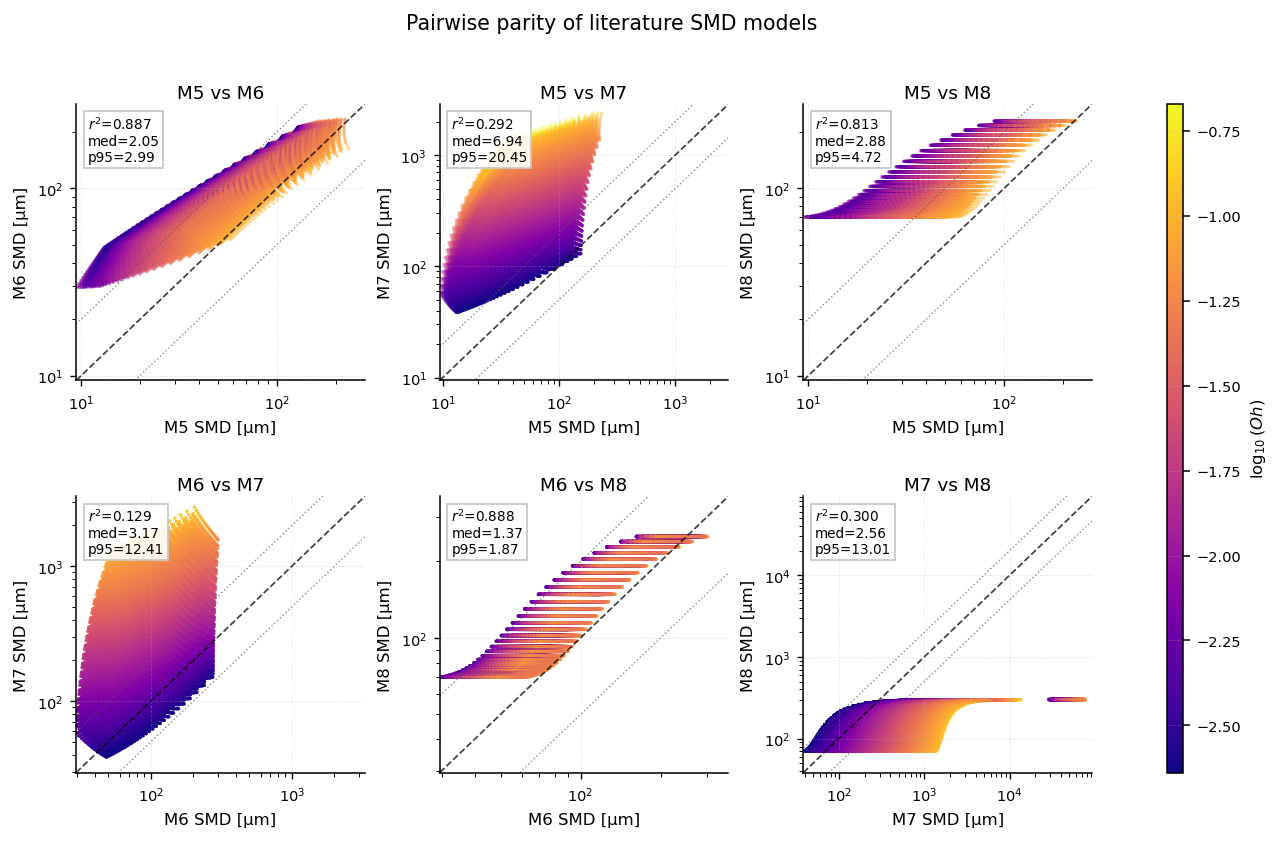

Plot 6 saved.


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 6 — Pairwise parity across literature models (M5–M8).
# Report-ready layout: short axis labels + dedicated colourbar column.
# ─────────────────────────────────────────────────────────────────────────────

lit_order   = ['M5', 'M6', 'M7', 'M8']
pairs = [('M5','M6'), ('M5','M7'), ('M5','M8'),
         ('M6','M7'), ('M6','M8'), ('M7','M8')]

Oh_valid  = df['Oh'].replace(0, np.nan).dropna()
oh_lo, oh_hi = np.log10(Oh_valid.min()), np.log10(Oh_valid.max())
oh_norm = Normalize(vmin=oh_lo, vmax=oh_hi)

fig = plt.figure(figsize=(10.2, 6.2))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.055], wspace=0.34, hspace=0.42)
axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(6)]
cax = fig.add_subplot(gs[:, 3])

for idx, (m_a, m_b) in enumerate(pairs):
    ax = axes[idx]
    x  = df[f'{m_a}_um']
    y  = df[f'{m_b}_um']
    valid = ~x.isna() & ~y.isna() & (x > 0) & (y > 0)

    if valid.sum() == 0:
        ax.text(0.5, 0.5, 'No overlap', transform=ax.transAxes,
                ha='center', va='center')
        ax.set_title(f'{m_a} vs {m_b}')
        continue

    xv = x[valid].values
    yv = y[valid].values
    cv = np.log10(df.loc[valid, 'Oh'].values)

    ax.scatter(xv, yv, c=cv, cmap='plasma', s=3.0, alpha=0.48,
               norm=oh_norm, edgecolors='none', rasterized=True)

    ax.set_xscale('log'); ax.set_yscale('log')

    lo = max(min(xv.min(), yv.min()), 1.0)
    hi = max(xv.max(), yv.max()) * 1.2
    diag = np.array([lo, hi])
    ax.plot(diag, diag,   color='black', ls='--', lw=0.9, alpha=0.75)
    ax.plot(diag, diag*2, color='0.35',  ls=':',  lw=0.75, alpha=0.65)
    ax.plot(diag, diag/2, color='0.35',  ls=':',  lw=0.75, alpha=0.65)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)

    r, _ = stats.pearsonr(np.log10(xv), np.log10(yv))
    med_ratio = np.median(np.maximum(xv, yv) / np.minimum(xv, yv))
    p95_ratio = np.quantile(np.maximum(xv, yv) / np.minimum(xv, yv), 0.95)
    ax.text(0.04, 0.96,
            f'$r^2$={r**2:.3f}\nmed={med_ratio:.2f}\np95={p95_ratio:.2f}',
            transform=ax.transAxes, fontsize=7.0, va='top',
            bbox=dict(facecolor='white', edgecolor='0.78', alpha=0.90, pad=2))

    ax.set_xlabel(f'{m_a} SMD [μm]')
    ax.set_ylabel(f'{m_b} SMD [μm]')
    ax.set_title(f'{m_a} vs {m_b}', pad=3)
    format_log_axis(ax, 'both')

sm = plt.cm.ScalarMappable(cmap='plasma', norm=oh_norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('$\log_{10}(Oh)$')

fig.suptitle('Pairwise parity of literature SMD models', fontsize=10.5, y=0.985)
save_report_figure(fig, 'plot6_parity_literature.png')
plt.show()
print('Plot 6 saved.')


### Plot 7 — Inter-model scatter vs the three dimensionless groups

Three panels. Each panel plots $\sigma_{\log}$ against one of the dimensionless groups ($We$, $Re$, $Oh$), with both the full-set median (solid dark) and literature-subset median (dashed red) shown. The shaded bands are the inter-quartile ranges.
- **$We$ panel.** A trough sits in the $We \approx 25$–$100$ band. This is the atomisation regime the literature correlations were originally fitted in, and it is where they agree most closely. Scatter rises sharply at low $We$ (models extrapolating into sub-atomisation) and climbs again at very high $We$ (extrapolating above calibration).
- **$Re$ panel.** Scatter rises as $Re$ falls. Low $Re$ means viscous-dominated breakup, where the different viscosity terms in M5–M8 pull in different directions.
- **$Oh$ panel.** Scatter grows monotonically with $Oh$, from about 0.45 at $Oh \approx 0.005$ up to over 1.0 at $Oh > 0.05$. $Oh$ is the single cleanest predictor of disagreement because it packages viscosity, surface tension, density, and diameter into one number.


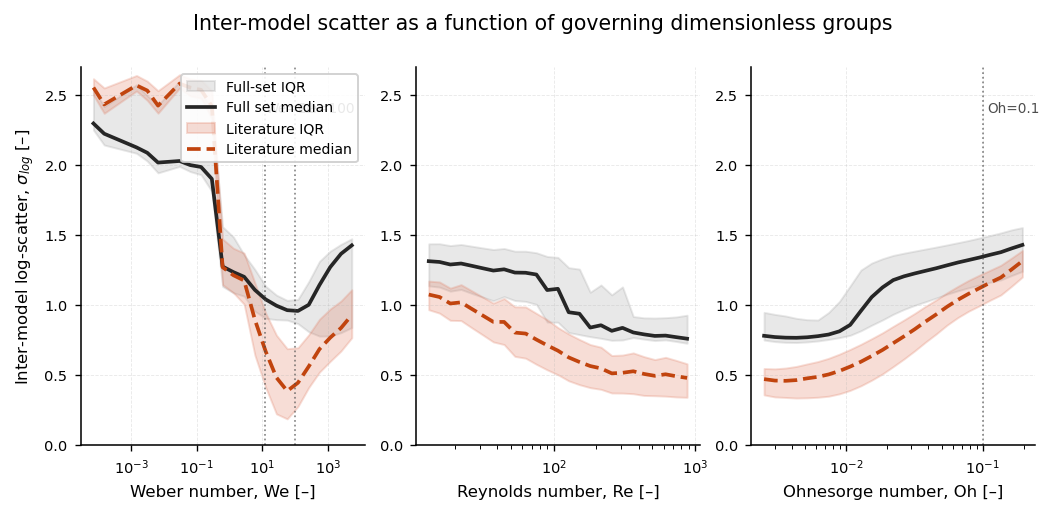

Plot 7 saved.


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 7 — σ_log as a function of the three Π-groups (We, Re, Oh).
# Literature subset (dashed median + IQR band) overlaid on full set (solid).
# ─────────────────────────────────────────────────────────────────────────────

def _binned_stats(x_col, y_col, n_bins=25, log_x=True):
    sub = df[[x_col, y_col]].dropna()
    sub = sub[sub[x_col] > 0]
    if log_x:
        edges = np.logspace(np.log10(sub[x_col].min()),
                            np.log10(sub[x_col].max()), n_bins + 1)
        centres = np.sqrt(edges[:-1] * edges[1:])
    else:
        edges   = np.linspace(sub[x_col].min(), sub[x_col].max(), n_bins + 1)
        centres = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.clip(np.digitize(sub[x_col], edges) - 1, 0, n_bins - 1)
    out = sub.groupby(bin_idx)[y_col].agg(
        ['median', lambda s: s.quantile(0.25), lambda s: s.quantile(0.75)])
    out.columns  = ['median', 'q25', 'q75']
    out['centre'] = centres[out.index]
    return out

panels = [
    ('We', 'Weber number, We [–]',       [(12, 'We=12'), (100, 'We=100')]),
    ('Re', 'Reynolds number, Re [–]',    []),
    ('Oh', 'Ohnesorge number, Oh [–]',   [(0.1, 'Oh=0.1')]),
]

fig = plt.figure(figsize=(8.8, 3.5))
gs = fig.add_gridspec(1, 3, wspace=0.18)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax, (var, xlabel, markers) in zip(axes, panels):
    bs_full = _binned_stats(var, 'sigma_log_full', n_bins=25)
    bs_lit  = _binned_stats(var, 'sigma_log_lit',  n_bins=25)

    ax.fill_between(bs_full['centre'], bs_full['q25'], bs_full['q75'],
                    color='0.55', alpha=0.20, label='Full-set IQR')
    ax.plot(bs_full['centre'], bs_full['median'],
            color='0.15', lw=1.9, label='Full set median')

    ax.fill_between(bs_lit['centre'], bs_lit['q25'], bs_lit['q75'],
                    color='#E07A5F', alpha=0.25, label='Literature IQR')
    ax.plot(bs_lit['centre'], bs_lit['median'],
            color='#C1440E', lw=1.9, linestyle='--', label='Literature median')

    for x_val, lbl in markers:
        ax.axvline(x_val, color='0.3', ls=':', lw=0.9, alpha=0.65)
        ax.text(x_val * 1.08, 2.38, lbl, fontsize=7, color='0.3')

    ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 2.7)
    format_log_axis(ax, 'x')

axes[0].set_ylabel('Inter-model log-scatter, $\sigma_{log}$ [–]')
axes[0].legend(fontsize=7.2, loc='upper right', frameon=True, framealpha=0.88)

fig.suptitle('Inter-model scatter as a function of governing dimensionless groups', fontsize=10.5, y=0.99)
save_report_figure(fig, 'plot7_sigma_log_vs_pi_groups.png')
plt.show()
print('Plot 7 saved.')


### Plot 8 — Inter-model scatter across all three dimensionless-group planes

Three panels, one for each pair of dimensionless groups ($We$–$Re$, $We$–$Oh$, $Re$–$Oh$). A representative sample of sweep points is plotted for readability; colour is the literature-subset $\sigma_{\log}$ (red = models diverge, green = they agree).

- The **$We$–$Oh$** panel is the most informative — a clear green region sits at high $We$, low $Oh$ (the atomisation regime the correlations were fitted in), with red regions at low $We$ (sub-atomisation) and high $Oh$ (viscosity-dominated).
- The **$We$–$Re$** panel adds a clean view of how scatter depends on the balance between gas-side and liquid-side effects.
- The **$Re$–$Oh$** panel shows the limitation of the sweep: $Re$ and $Oh$ both depend strongly on $\mu_l$, so sweep points cluster along a narrow anti-correlated band rather than filling the plane. The colour still reads cleanly along that band (high $Oh$ = red) but the panel can't say anything about regions that weren't populated.


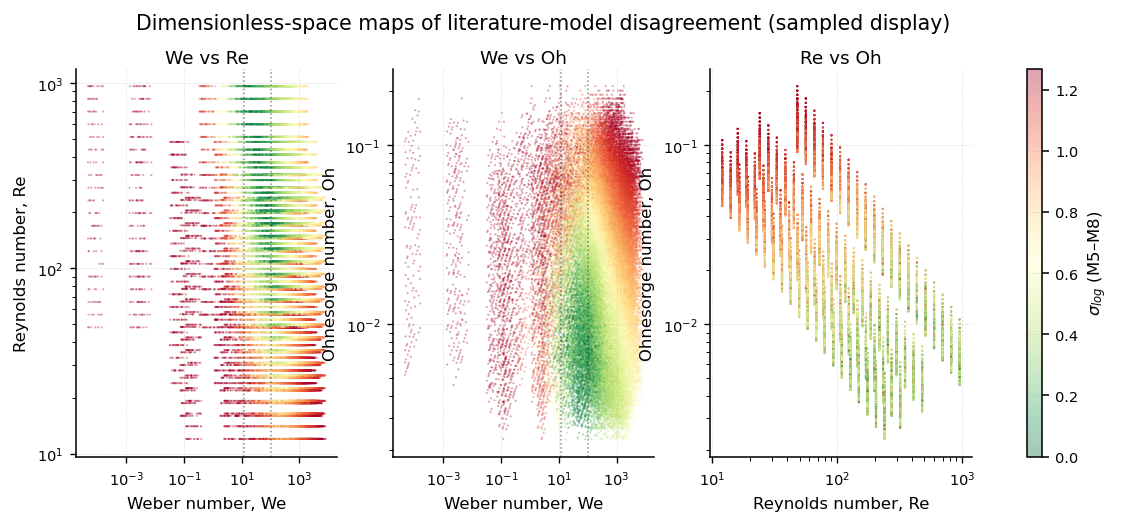

Plot 8 saved.


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 8 — Pi-group pair scatter, coloured by literature σ_log
# Three panels: We-Re, We-Oh, Re-Oh. All 192k sweep points, log-log axes.
# ─────────────────────────────────────────────────────────────────────────────

valid = (df['sigma_log_lit'].notna()
         & (df['We'] > 0) & (df['Re'] > 0) & (df['Oh'] > 0))
sub = df[valid]
# Downsample only for the visual scatter plot. The statistics and heatmap use all data.
sub_plot = sub.sample(n=min(len(sub), 60000), random_state=8)

fig = plt.figure(figsize=(8.9, 3.6))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.055], wspace=0.28)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
cax = fig.add_subplot(gs[0, 3])
pairs   = [('We', 'Re'), ('We', 'Oh'), ('Re', 'Oh')]
ax_labs = {'We': 'Weber number, We',
           'Re': 'Reynolds number, Re',
           'Oh': 'Ohnesorge number, Oh'}

slog_top = sub['sigma_log_lit'].quantile(0.95)

for ax, (xk, yk) in zip(axes, pairs):
    sc = ax.scatter(sub_plot[xk], sub_plot[yk], c=sub_plot['sigma_log_lit'],
                    cmap='RdYlGn_r', s=1.2, alpha=0.36,
                    norm=Normalize(vmin=0, vmax=slog_top),
                    edgecolors='none', rasterized=True)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(ax_labs[xk]); ax.set_ylabel(ax_labs[yk])
    ax.set_title(f'{xk} vs {yk}', pad=3)
    format_log_axis(ax, 'both')

    if xk == 'We':
        for we_b in (12, 100):
            ax.axvline(we_b, color='0.2', ls=':', lw=0.8, alpha=0.55)

cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('$\sigma_{log}$ (M5–M8)')

fig.suptitle('Dimensionless-space maps of literature-model disagreement (sampled display)', fontsize=10.5, y=0.99)
save_report_figure(fig, 'plot8_pi_pair_maps.png')
plt.show()
print('Plot 8 saved.')


### Plot 8B — $We$–$Oh$ reliability heatmap

Plot 8 shows every point individually. This heatmap compresses the same information into regime bins so that it can be used directly in the report discussion. Each cell shows the median literature-subset scatter in that $We$–$Oh$ region; the annotation also gives the corresponding geometric spread factor, $\exp(\sigma_{\log})$.


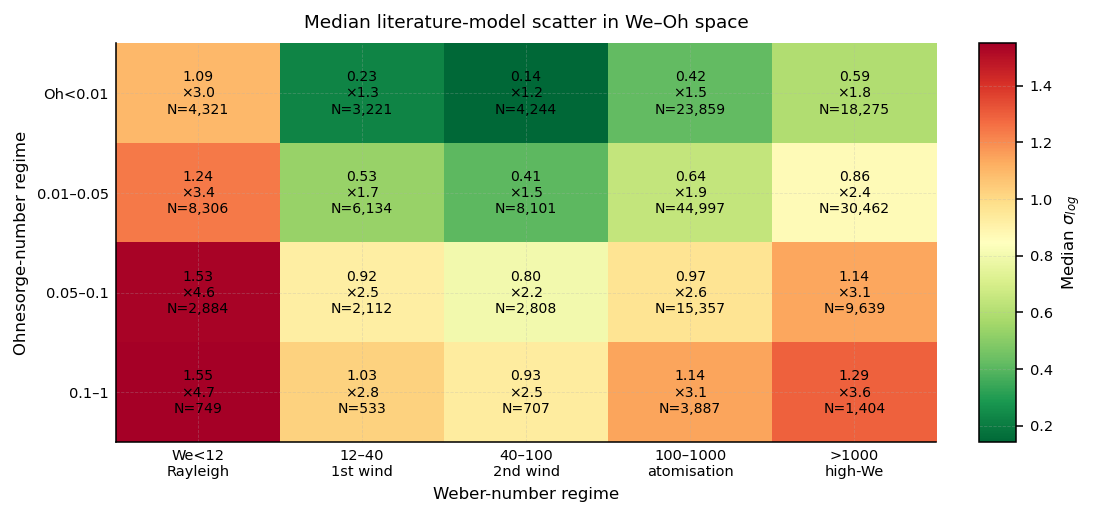

Plot 8B saved.
Reading: the greenest cells are the most reliable cross-model regions; red cells are
the regions where the choice of correlation has the largest engineering effect.


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 8B — We–Oh reliability heatmap using median literature σ_log
# This is a compact, report-friendly version of the dimensionless-space result.
# ─────────────────────────────────────────────────────────────────────────────

if 'We_bin' not in df.columns:
    we_bins   = [0, 12, 40, 100, 1000, 1e6]
    we_labels = ['We<12\nRayleigh', '12–40\n1st wind', '40–100\n2nd wind',
                 '100–1000\natomisation', '>1000\nhigh-We']
    df['We_bin'] = pd.cut(df['We'], bins=we_bins, labels=we_labels)
if 'Oh_bin' not in df.columns:
    oh_bins   = [0, 0.01, 0.05, 0.1, 1, 10]
    oh_labels = ['Oh<0.01', '0.01–0.05', '0.05–0.1', '0.1–1', '>1']
    df['Oh_bin'] = pd.cut(df['Oh'], bins=oh_bins, labels=oh_labels)

heat = (df.dropna(subset=['We_bin', 'Oh_bin', 'sigma_log_lit'])
          .groupby(['Oh_bin', 'We_bin'], observed=True)['sigma_log_lit']
          .median()
          .unstack('We_bin'))
count = (df.dropna(subset=['We_bin', 'Oh_bin', 'sigma_log_lit'])
           .groupby(['Oh_bin', 'We_bin'], observed=True)['sigma_log_lit']
           .count()
           .unstack('We_bin'))

fig = plt.figure(figsize=(8.3, 3.7))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.045], wspace=0.10)
ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
im = ax.imshow(heat.values.astype(float), aspect='auto', cmap='RdYlGn_r')

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_yticks(np.arange(len(heat.index)))
ax.set_xticklabels([str(c).replace(' (', '\n(') for c in heat.columns], rotation=0, ha='center')
ax.set_yticklabels([str(i) for i in heat.index])
ax.set_xlabel('Weber-number regime')
ax.set_ylabel('Ohnesorge-number regime')
ax.set_title('Median literature-model scatter in We–Oh space', pad=8)
ax.tick_params(length=0)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Median $\sigma_{log}$')

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        n = count.iloc[i, j] if not np.isnan(count.iloc[i, j]) else 0
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}\n×{np.exp(val):.1f}\nN={int(n):,}',
                    ha='center', va='center', fontsize=7.2)

save_report_figure(fig, 'plot8B_we_oh_reliability_heatmap.png')
plt.show()
print('Plot 8B saved.')
print('Reading: the greenest cells are the most reliable cross-model regions; red cells are')
print('the regions where the choice of correlation has the largest engineering effect.')


### Plot 9 — How each literature model maps SMD onto dimensionless space

Four panels, one per literature model (M5, M6, M7, M8). Each panel shows a representative sample of sweep points in $We$–$Oh$ space, coloured by that model's predicted SMD on a shared logarithmic scale.

This plot turns the abstract scatter statistics from Section 7 into a concrete visual. Comparing the four panels side-by-side shows *where in dimensionless space each model puts its predictions*

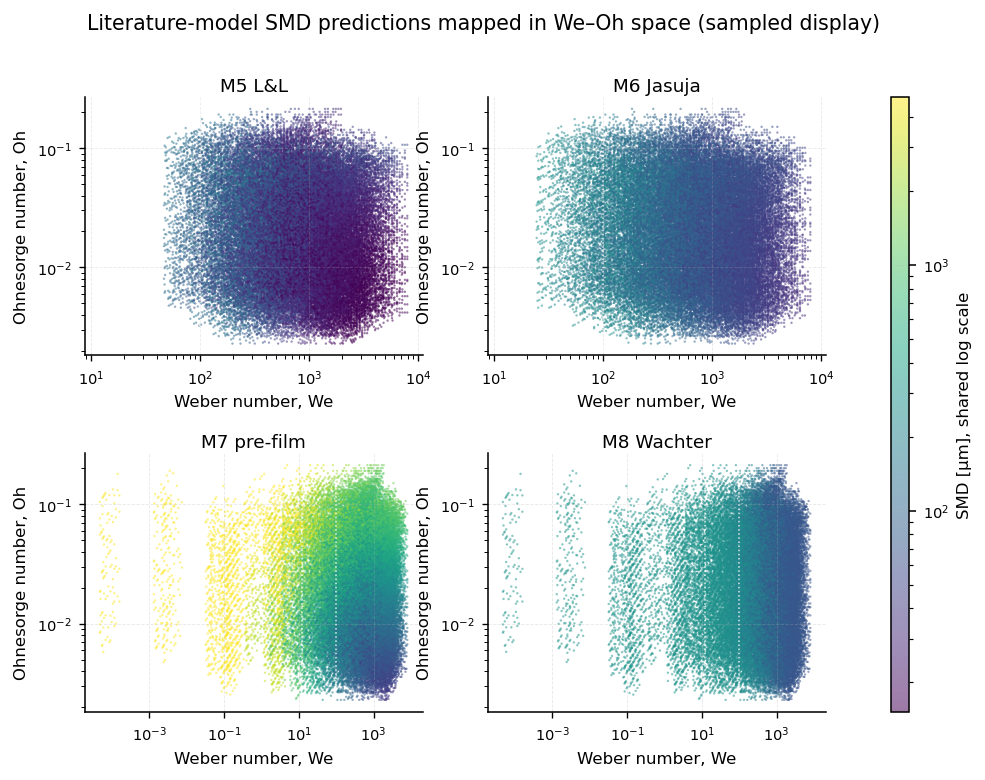

Plot 9 saved.


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 9 — Per-model SMD response in We-Oh space (literature models only)
# 2x2 panels with one shared colourbar for direct comparison.
# ─────────────────────────────────────────────────────────────────────────────

lit = ['M5', 'M6', 'M7', 'M8']

all_lit_vals = np.concatenate([df[f'{m}_um'].dropna().values for m in lit])
all_lit_vals = all_lit_vals[all_lit_vals > 0]
vmin = np.nanpercentile(all_lit_vals, 1)
vmax = np.nanpercentile(all_lit_vals, 99)

fig = plt.figure(figsize=(7.6, 5.7))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.055], wspace=0.28, hspace=0.38)
axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]
cax = fig.add_subplot(gs[:, 2])

for ax, m in zip(axes, lit):
    col = f'{m}_um'
    valid = df[col].notna() & (df[col] > 0) & (df.We > 0) & (df.Oh > 0)
    sub = df[valid]
    sub_plot = sub.sample(n=min(len(sub), 50000), random_state=9)

    sc = ax.scatter(sub_plot.We, sub_plot.Oh, c=sub_plot[col],
                    cmap='viridis', s=1.5, alpha=0.52,
                    norm=LogNorm(vmin=vmin, vmax=vmax),
                    edgecolors='none', rasterized=True)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Weber number, We')
    ax.set_ylabel('Ohnesorge number, Oh')
    ax.set_title(MODEL_SHORT_LABELS[m], pad=3)
    format_log_axis(ax, 'both')
    for we_b in (12, 100):
        ax.axvline(we_b, color='white', ls=':', lw=0.8, alpha=0.8)

cbar = fig.colorbar(sc, cax=cax)
cbar.set_label('SMD [μm], shared log scale')

fig.suptitle('Literature-model SMD predictions mapped in We–Oh space (sampled display)', fontsize=10.5, y=0.985)
save_report_figure(fig, 'plot9_per_model_weoh.png')
plt.show()
print('Plot 9 saved.')


### Plot 10 — Which model is the outlier in each region of Π-space?

Two panels at fixed $GLR \approx 1.2$ (where all four literature models are valid). Every sweep point at that GLR is coloured by *which* literature model gave the largest (left panel) or smallest (right panel) SMD prediction.

Valid points at GLR = 1.19:  4,800

  Model  | % times MAX | % times MIN
  -------|-------------|-------------
  M5     |      0.0    |     99.6
  M6     |      0.0    |      0.4
  M7     |     72.1    |      0.0
  M8     |     27.9    |      0.0


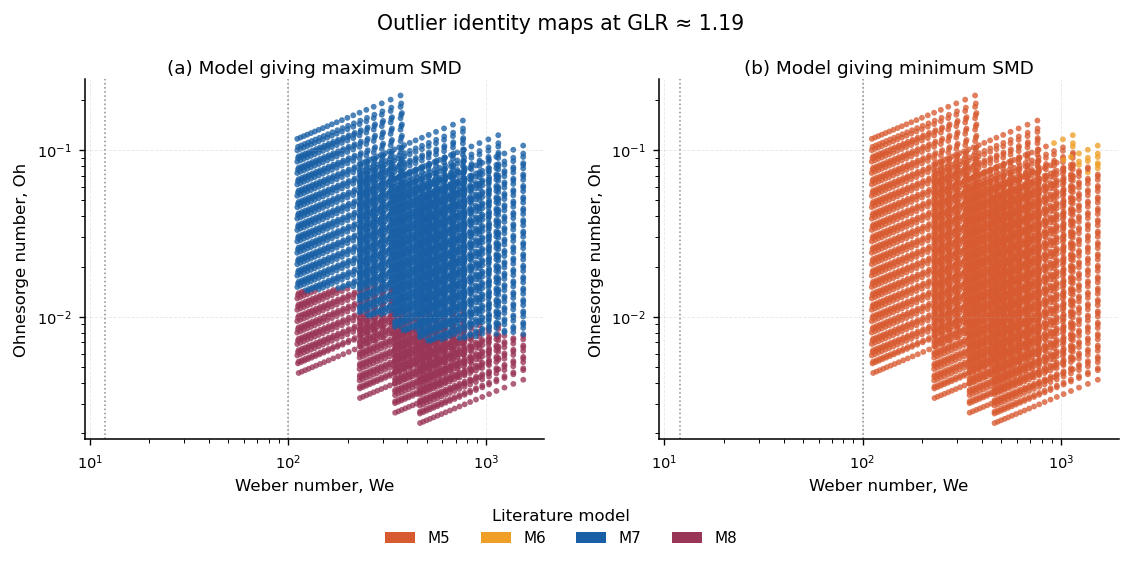


Plot 10 saved.


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 10 — argmax and argmin model in We-Oh space
# Fixed GLR where all 4 literature models are valid (GLR ≈ 1.2).
# ─────────────────────────────────────────────────────────────────────────────

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

GLR_target = 1.2
GLR_val = GLR_range[np.argmin(np.abs(GLR_range - GLR_target))]

mask = np.isclose(df.GLR, GLR_val, rtol=1e-3)
sub  = df[mask].copy()

lit = ['M5', 'M6', 'M7', 'M8']
arr = sub[lit].values.astype(float)
arr = np.where(arr > 0, arr, np.nan)

all_valid = np.all(~np.isnan(arr), axis=1)
sub = sub[all_valid].reset_index(drop=True)
arr = arr[all_valid]

if len(sub) == 0:
    print(f'No points with all 4 literature models valid at GLR={GLR_val:.2f}. Try a higher GLR.')
else:
    print(f'Valid points at GLR = {GLR_val:.2f}:  {len(sub):,}')

    max_idx = np.nanargmax(arr, axis=1)
    min_idx = np.nanargmin(arr, axis=1)

    print('\n  Model  | % times MAX | % times MIN')
    print('  -------|-------------|-------------')
    for i, m in enumerate(lit):
        pct_max = 100 * np.sum(max_idx == i) / len(sub)
        pct_min = 100 * np.sum(min_idx == i) / len(sub)
        print(f'  {m}     |   {pct_max:6.1f}    |   {pct_min:6.1f}')

    cat_colours = ['#D85A30', '#EF9F27', '#185FA5', '#993556']
    cmap = ListedColormap(cat_colours)
    norm = BoundaryNorm([0, 1, 2, 3, 4], cmap.N)

    fig = plt.figure(figsize=(8.3, 3.9))
    gs = fig.add_gridspec(1, 2, wspace=0.25)
    ax1 = fig.add_subplot(gs[0, 0]); ax2 = fig.add_subplot(gs[0, 1])
    for ax, idx_arr, title in [
        (ax1, max_idx, f'(a) Model giving maximum SMD'),
        (ax2, min_idx, f'(b) Model giving minimum SMD'),
    ]:
        ax.scatter(sub.We, sub.Oh, c=idx_arr,
                   cmap=cmap, norm=norm, s=9, alpha=0.78,
                   edgecolors='none', rasterized=True)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel('Weber number, We')
        ax.set_ylabel('Ohnesorge number, Oh')
        ax.set_title(title, pad=3)
        format_log_axis(ax, 'both')
        for we_b in (12, 100):
            ax.axvline(we_b, color='0.2', ls=':', lw=0.8, alpha=0.55)

    handles = [Patch(facecolor=cat_colours[i], label=lit[i]) for i in range(len(lit))]
    fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02),
               ncol=4, frameon=False, title='Literature model')
    fig.suptitle(f'Outlier identity maps at GLR ≈ {GLR_val:.2f}', fontsize=10.5, y=0.98)
    fig.subplots_adjust(bottom=0.20, top=0.86, left=0.09, right=0.98)
    save_report_figure(fig, 'plot10_outlier_map.png')
    plt.show()
    print('\nPlot 10 saved.')


---

## Section 9 — Pressure scaling (M8 only)

### Plot 11 — M8 pressure scaling

M8 is the only model with an explicit pressure term. The others would need ad-hoc $\rho_g$ adjustments to handle elevated pressures, which wouldn't be a clean comparison.

This section sweeps system pressure from 1 to 21 bar at three gas velocities and reproduces the shape of Figure 9 in Wachter et al. (2021).

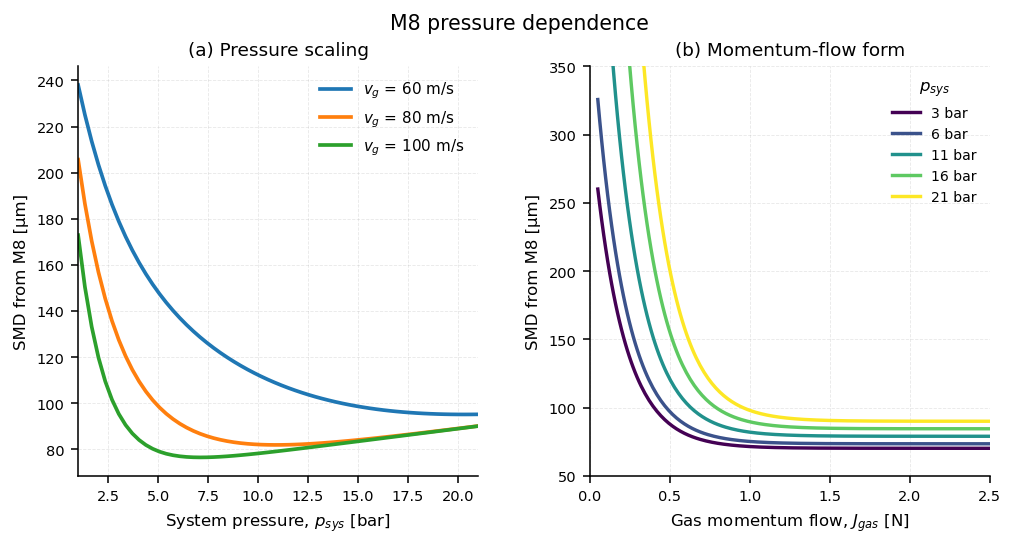

Plot 11 saved.


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# PRESSURE SCALING ANALYSIS — Model M8 (Wachter et al., 2021)
# Sweep: P_sys = 1–21 bar at fixed gas velocities
# ─────────────────────────────────────────────────────────────────────────────

p_range    = np.linspace(1e5, 21e5, 60)
vgas_sweep = [60.0, 80.0, 100.0]
B_param    = 0.19

fig = plt.figure(figsize=(8.4, 3.8))
gs = fig.add_gridspec(1, 2, wspace=0.28)
ax1 = fig.add_subplot(gs[0, 0]); ax2 = fig.add_subplot(gs[0, 1])

for vg in vgas_sweep:
    smd_um_list = []
    J_list      = []
    for p_pa in p_range:
        p_bar   = p_pa / 1e5
        rho_g_p = p_pa / (287.0 * 293.0)
        J_gas_p = vg**2 * rho_g_p * A_gas_W
        A_p     = 3.0 * p_bar**2 + 220.0
        C_p     = 1.1 * p_bar + 67.0
        smd_um  = A_p * np.exp(-J_gas_p / B_param) + C_p
        smd_um_list.append(smd_um)
        J_list.append(J_gas_p)

    ax1.plot(p_range / 1e5, smd_um_list,
             linewidth=1.9, label=f'$v_g$ = {vg:.0f} m/s')

ax1.set_xlabel('System pressure, $p_{sys}$ [bar]')
ax1.set_ylabel('SMD from M8 [μm]')
ax1.set_title('(a) Pressure scaling')
ax1.legend(frameon=False)
ax1.set_xlim(1, 21)

pressures_plot = [3e5, 6e5, 11e5, 16e5, 21e5]
J_sweep        = np.linspace(0.05, 2.5, 200)
c_map_p        = cm.get_cmap('viridis', len(pressures_plot))

for i_p, p_pa in enumerate(pressures_plot):
    p_bar  = p_pa / 1e5
    A_p    = 3.0 * p_bar**2 + 220.0
    C_p    = 1.1 * p_bar + 67.0
    smd_um = A_p * np.exp(-J_sweep / B_param) + C_p
    ax2.plot(J_sweep, smd_um, color=c_map_p(i_p / len(pressures_plot)),
             linewidth=1.75, label=f'{p_bar:.0f} bar')

ax2.set_xlabel('Gas momentum flow, $J_{gas}$ [N]')
ax2.set_ylabel('SMD from M8 [μm]')
ax2.set_title('(b) Momentum-flow form')
ax2.legend(title='$p_{sys}$', fontsize=7.2, frameon=False)
ax2.set_xlim(0, 2.5)
ax2.set_ylim(50, 350)

fig.suptitle('M8 pressure dependence', fontsize=10.5, y=0.98)
save_report_figure(fig, 'plot11_M8_pressure_scaling.png')
plt.show()
print('Plot 11 saved.')


---

## Section 10 — Saving and reloading the sweep

The full 192 000-point sweep runs in about 3 seconds, so there is no need to cache it unless you want a shareable file. Two helper functions are provided:

- `save_sweep(df)` writes the essential columns to `plots/SMD_sweep_data.csv.gz` (about 8 MB).
- `load_sweep()` reads that CSV back and restores the derived columns so downstream analysis still works.

Neither function runs automatically. Call `save_sweep(df)` only when you want a copy on disk. The default flow is to run Sections 1–9 and work with the `df` in memory.


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# SAVE / LOAD helpers for the sweep DataFrame.
# Neither runs automatically — call them explicitly when needed.
# ─────────────────────────────────────────────────────────────────────────────

import os

_CSV_PATH = plot_path('SMD_sweep_data.csv.gz')

# Essential columns — enough to regenerate everything else on load.
_ESSENTIAL_COLS = (
    ['GLR', 'd0', 'rho_l', 'rho_g', 'mu_l', 'sigma', 'P_g',
     'U_g', 'U_l', 'U_R', 'We', 'Re', 'Oh']
    + [m for m in ['M1','M2','M3','M4','M5','M6','M7','M8']]   # raw SMD in metres
    + ['sigma_log_full', 'sigma_log_lit', 'ratio_full', 'ratio_lit']
)

def save_sweep(df_in, path=_CSV_PATH):
    # Write essential columns only. Derived ones regenerate on load.
    cols = [c for c in _ESSENTIAL_COLS if c in df_in.columns]
    df_in[cols].to_csv(path, index=False, compression='gzip')
    size_mb = os.path.getsize(path) / (1024**2)
    print(f'Saved {len(df_in):,} rows × {len(cols)} essential cols to {path}')
    print(f'  File size: {size_mb:.1f} MB')

def load_sweep(path=_CSV_PATH):
    # Load and restore derived columns so downstream analysis code still works.
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'No cached sweep at {path}. Run Sections 3–6 first, then save_sweep(df).')
    df = pd.read_csv(path)
    # Restore derived columns
    model_cols = ['M1','M2','M3','M4','M5','M6','M7','M8']
    for m in model_cols:
        df[f'{m}_um']     = df[m] * 1e6
        df[f'{m}_over_d0'] = df[m] / df['d0']
        df[f'ln_{m}']     = np.log(df[m].where(df[m] > 0))
    df['sigma_log'] = df['sigma_log_full']
    df['regime']    = np.where(df['mu_l'] >= MU_THRESHOLD,
                               'Viscous (M1/M2)', 'Non-viscous (M3/M4)')
    df['mu_l_mPa']  = df['mu_l'] * 1e3
    df['sigma_mN']  = df['sigma'] * 1e3
    df['d0_mm']     = df['d0']   * 1e3
    print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} cols from {path}')
    return df

print('Helpers defined:')
print('  save_sweep(df)   — write essential columns to', _CSV_PATH)
print('  df = load_sweep() — read them back and restore derived columns')
print()
print('Neither runs automatically. Call save_sweep(df) if you want a cached copy.')


Helpers defined:
  save_sweep(df)   — write essential columns to C:\Users\liamc\OneDrive - University of Pretoria\Fourth Year\CSC\Code\plots_word_ready\SMD_sweep_data.csv.gz
  df = load_sweep() — read them back and restore derived columns

Neither runs automatically. Call save_sweep(df) if you want a cached copy.


*Project PLdV01 (#4085), Department of Chemical Engineering, University of Pretoria. Contact: Prof. P.L. de Vaal, Ms Nyasha Chideme.*
